# ECOSYSTEME
## Prétraitement de données

### Etape 1 : Faites les importations des bibliothèques nécessaires

In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Etape 2 : Importer les données du fichier "dataset_ProjetML_2026.csv"

In [2]:
df = pd.read_csv("dataset_ProjetML_2026.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### Etape 3 : Afficher un échontillon du dataframe

In [3]:
df.head(10)

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.000000,1.000000,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.000000,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.000000,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.000000,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.000000,1.000000,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...
5,32.954775,43.962633,0.000000,0.352356,4.0,3.295478,Plastique,Usine_B,Déchet plastique collecté à l'Usine B. Poids 3...
6,187.760007,400.170299,0.000000,0.012702,8.0,5.632800,Verre,Collecte_Citoyenne,Déchets en verre identifiés lors d'une collect...
7,132.167170,252.346840,0.000000,0.011275,9.0,3.965015,Verre,Collecte_Citoyenne,Déchets en verre identifiés via la collecte ci...
8,16.712285,71.655161,0.000000,1.000000,1.0,0.835614,Papier,Usine_A,Feuilles et cartons collectés provenant de l'U...
9,60.078655,121.096923,0.953797,1.000000,7.0,18.023597,Métal,Centre_Tri,Métal de récupération au centre de tri municip...


### Etape 4 : Afficher toutes les variables du dataset et leurs types respectifs

In [4]:
df.dtypes

Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie            object
Source               object
Rapport_Collecte     object
dtype: object

### Etape 5 : Afficher la description du dataset

In [5]:
df.describe()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


### Etape 6 : Afficher les informations du dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB


### Etape 7 : Afficher le nombre de lignes et de colonnes du dataframe

In [7]:
df.shape
print("nombre de lignes:",df.shape[0])
print("nombre de colonnes:",df.shape[1])

nombre de lignes: 10500
nombre de colonnes: 9


### Etape 8 : Afficher les valeurs de chaque fearture

In [8]:
df['Categorie'].value_counts()

Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [9]:
df['Source'].value_counts()

Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64

### Etape 9 : Traiter les dedoublants

- Sélection des lignes dupliquées et calcul de leur nombre

In [10]:
duplicates = df[df.duplicated()]
len(duplicates)


776

- Afficher les premières lignes dupliquées

In [11]:
duplicates.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
1174,21.892241,61.029742,0.0,0.277253,3.0,2.189224,Plastique,Collecte_Citoyenne,Déchet plastique collecté lors d'une collecte ...
1177,16.246918,64.042902,0.0,1.000000,2.0,0.812346,Papier,Centre_Tri,Déchet de type papier identifié depuis le Cent...
1199,14.405010,5.252087,0.0,1.000000,2.0,0.720251,Papier,Collecte_Citoyenne,Lot de papier récupéré via la collecte citoyen...
1275,NaN,66.939429,0.0,0.535945,3.0,1.597395,Plastique,Usine_B,Emballages plastiques récupérés en provenance ...
1438,13.890695,36.215080,0.0,1.000000,1.0,0.694535,Papier,Centre_Tri,Déchet de type papier identifié au centre de t...


- Nombre de lignes dupliquées en ignorant la dernière colonne

In [12]:
df.duplicated(subset=df.columns[:-1]).sum()

np.int64(6344)

- Nombre de cas où les mêmes variables (features) ont plusieurs catégories différentes (conflits)

In [13]:
feature_cols = df.columns.drop('Categorie')

conflicts = (
    df.groupby(list(feature_cols))['Categorie']
      .nunique(dropna=False)
      .reset_index(name='nb_categories')
)

conflicts = conflicts[conflicts['nb_categories'] > 1]

len(conflicts)
# Détection des conflits : mêmes features mais catégories différentes
# Regroupe les données par les variables explicatives (sans la colonne Categorie)
# puis compte combien de catégories différentes existent pour chaque groupe
# On garde uniquement les cas où il y a plus d'une catégorie (conflit)
# len(conflicts) donne le nombre de ces conflits

0

- Supprimer les lignes dupliquées puis réinitialiser l’index

In [14]:
df = df.drop_duplicates().reset_index(drop=True)

- Vérifier la suppréssion

In [15]:
duplicates = df[df.duplicated()]
len(duplicates)



0

In [16]:
df.shape

(9724, 9)

In [17]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


- Afficher le nombre de colonne 

In [18]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

### Etape 10 : Traitement des valeurs Null (manquantes)

- Les colonnes qui  contiennent des valeurs nulls & le nombre de valeurs nulls

In [19]:
print(df.isna().sum())

Poids               974
Volume              537
Conductivite        972
Opacite             989
Rigidite            554
Prix_Revente        533
Categorie           511
Source              535
Rapport_Collecte      0
dtype: int64


- Sélection des colonnes numériques (int et float) du dataset

In [20]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente'],
      dtype='object')


- Selection des colonne catégories

In [21]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)


Index(['Categorie', 'Source', 'Rapport_Collecte'], dtype='object')


- Utilisation de la méthode MAR pour voir le pourcentage de Poids manquant par catégorie

In [22]:
df["Poids_missing"] = df["Poids"].isna().astype(int)

print("Pourcentage de Poids manquant par catégorie :")
display(df.groupby("Categorie")["Poids_missing"].mean() * 100)

print("Pourcentage de Poids manquant par source :")
display(df.groupby("Source")["Poids_missing"].mean() * 100)

Pourcentage de Poids manquant par catégorie :


Categorie
Métal        11.095700
Papier        9.268061
Plastique    10.733802
Verre         8.892617
Name: Poids_missing, dtype: float64

Pourcentage de Poids manquant par source :


Source
Centre_Tri             9.377818
Collecte_Citoyenne    10.419210
Usine_A               10.185968
Usine_B               10.381750
Name: Poids_missing, dtype: float64

- utilisation de la méthode MCAR pour détecter si les NaN sont indépendants

In [23]:
df["Poids_missing"] = df["Poids"].isna().astype(int)

df.groupby("Categorie")["Poids_missing"].mean()

Categorie
Métal        0.110957
Papier       0.092681
Plastique    0.107338
Verre        0.088926
Name: Poids_missing, dtype: float64

=>L’analyse des valeurs manquantes de la variable Poids a été réalisée en étudiant leur distribution selon la catégorie et la source. 
Les résultats montrent que le pourcentage de valeurs manquantes reste relativement stable entre les différentes catégories (entre 8.89% et 11.09%) et les différentes sources (entre 9.37% et 10.41%). 
Cela indique que les valeurs manquantes ne dépendent pas des variables observées. 
Par conséquent, ces données peuvent être considérées comme MCAR (Missing Completely At Random). 
Dans ce cas, une imputation simple comme la médiane est appropriée, tout en comparant avec des méthodes plus avancées comme KNNImputer.

=> Les valeurs manquantes de la variable Poids ne semblent pas totalement aléatoires.
Elles varient selon la catégorie ou la source, donc elles peuvent être considérées comme MAR.
Pour cette raison, plusieurs stratégies d’imputation sont comparées : médiane, KNNImputer et IterativeImputer.

-  Remplacer les valeurs manquantes par la valeur la plus fréquente (mode) pour chaque colonne

In [24]:
#df = df.dropna(subset=["Categorie"])

In [25]:
df["Categorie"] = df["Categorie"].fillna(df["Categorie"].mode()[0])
print(df["Categorie"])
df["Source"] = df["Source"].fillna(df["Source"].mode()[0])
print(df["Source"])

0          Papier
1       Plastique
2           Verre
3          Papier
4          Papier
          ...    
9719        Verre
9720        Verre
9721       Papier
9722    Plastique
9723        Verre
Name: Categorie, Length: 9724, dtype: object
0       Collecte_Citoyenne
1                  Usine_A
2                  Usine_B
3               Centre_Tri
4                  Usine_B
               ...        
9719               Usine_B
9720    Collecte_Citoyenne
9721    Collecte_Citoyenne
9722    Collecte_Citoyenne
9723               Usine_B
Name: Source, Length: 9724, dtype: object


=> Les valeurs manquantes de la variable cible Categorie ont été supprimées afin d’éviter d’introduire un biais dans le modèle.
Pour la variable catégorielle Source, les valeurs manquantes ont été remplacées par la modalité la plus fréquente (ou par une catégorie "Inconnu").

- Vérifier que les Nan pour les variables catégorique sont traités

In [26]:
print(df.isna().sum())

Poids               974
Volume              537
Conductivite        972
Opacite             989
Rigidite            554
Prix_Revente        533
Categorie             0
Source                0
Rapport_Collecte      0
Poids_missing         0
dtype: int64


- Traiter les Nan des variables numérique

In [27]:
df["Poids"] = df.groupby("Categorie")["Poids"].transform(lambda x: x.fillna(x.mean()))
df["Volume"] = df.groupby("Categorie")["Volume"].transform(lambda x: x.fillna(x.median()))
df["Prix_Revente"] = df.groupby("Categorie")["Prix_Revente"].transform(lambda x: x.fillna(x.median()))

In [28]:
df["Rigidite"] = df.groupby("Categorie")["Rigidite"].transform(lambda x: x.fillna(x.median()))
df["Conductivite"] = df.groupby("Categorie")["Conductivite"].transform(lambda x: x.fillna(x.median()))
df["Opacite"] = df.groupby("Categorie")["Opacite"].transform(lambda x: x.fillna(x.median()))

- Vérifier que les Nan sont disparus 

In [29]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
Poids_missing       0
dtype: int64


- Voir un échantillon du dataset aprés le traitement des Nan

In [30]:
df.shape

(9724, 10)

### Etape 11 :  La dataset est Equilibre ou Non

In [31]:
df["Categorie"].value_counts()

Categorie
Plastique    3073
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

In [32]:
#Le dataset présente un léger déséquilibre entre les classes. 
#La classe "Plastique" est dominante par rapport aux autres classes. 
#Cependant, ce déséquilibre reste modéré et peut être acceptable selon le modèle utilisé.

- Equilibrer la dataset avec class_weight

In [33]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight="balanced")


In [34]:
df.Categorie.value_counts()

Categorie
Plastique    3073
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

### Etape 12 : La corrélation entre les variables

<Axes: >

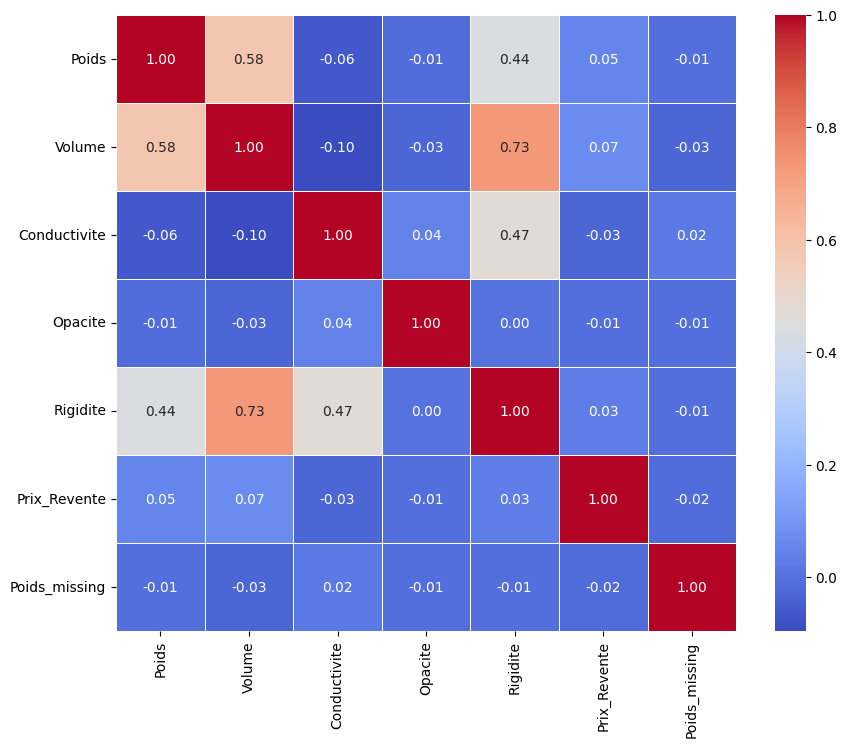

In [35]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

<Axes: >

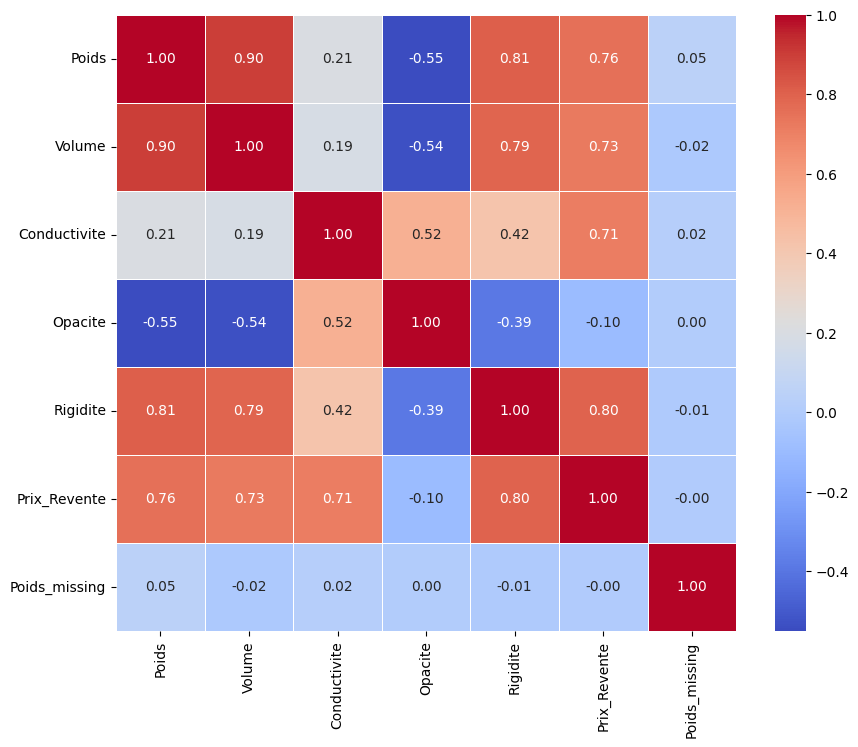

In [36]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

<Axes: >

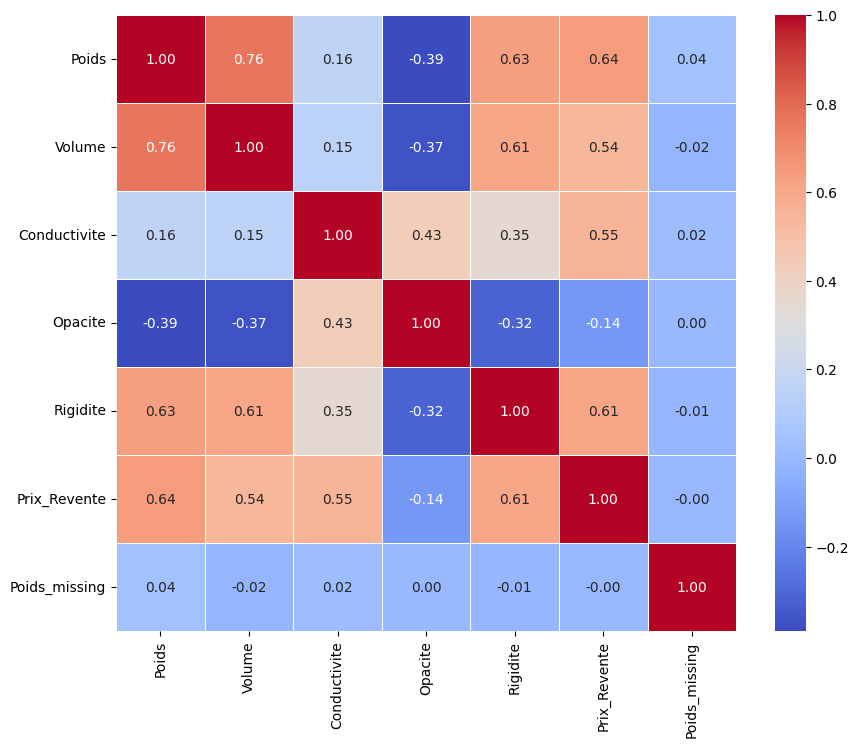

In [37]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

=> Dans ce travail, nous avons utilisé plusieurs méthodes de corrélation pour analyser les relations entre les variables. 
La corrélation de Pearson permet de mesurer les relations linéaires entre les variables numériques. 
La corrélation de Spearman est utilisée pour détecter des relations même non linéaires et elle est plus robuste face aux valeurs aberrantes. 
Enfin, la corrélation de Kendall, plus précise mais plus lente, peut être utilisée pour confirmer les résultats. 
Ces méthodes permettent de mieux comprendre les liens entre les variables.

### Etape 13 : Traiter les outliers

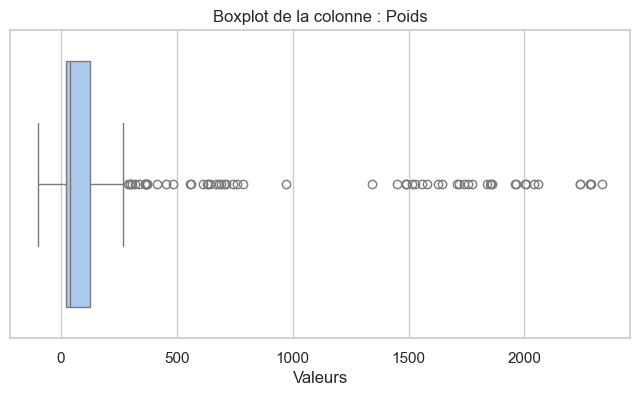

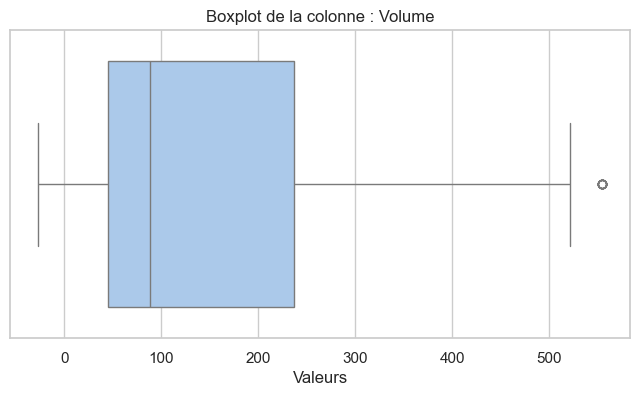

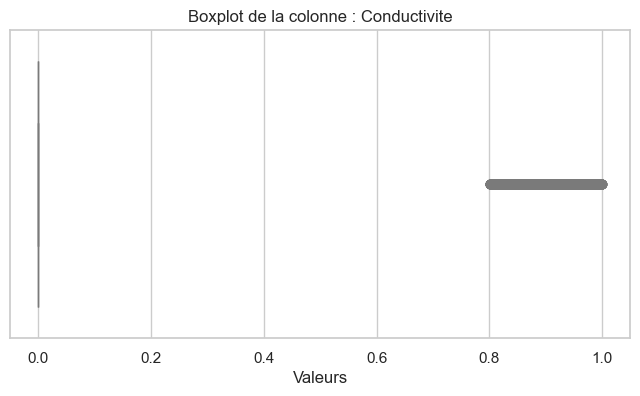

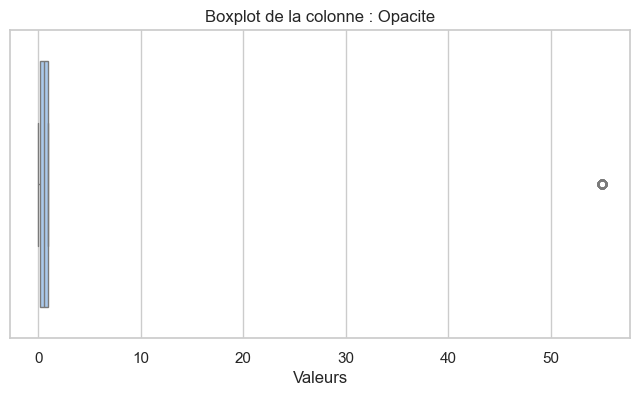

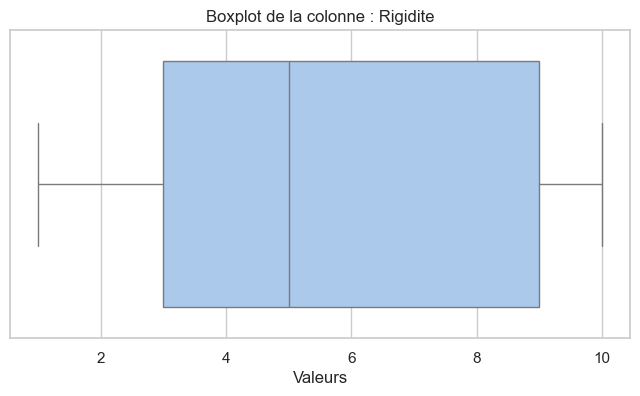

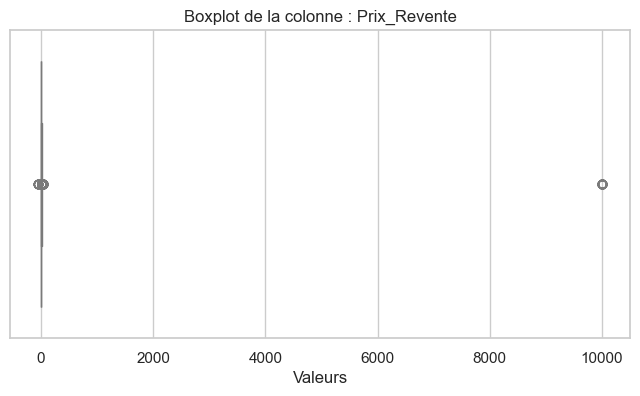

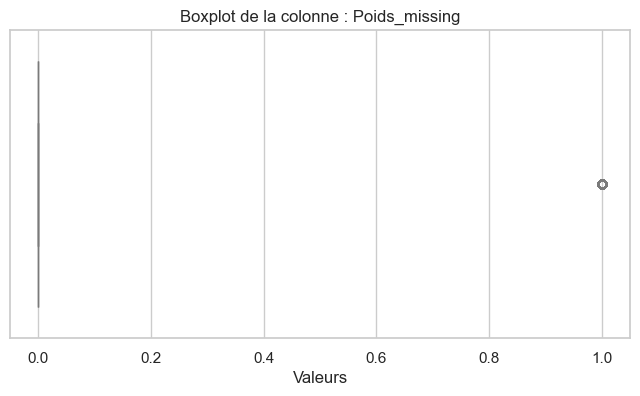

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.set(style='whitegrid')
for col in numeric_cols:
 plt.figure(figsize=(8, 4)) # Ajuster la taille de chaque figure
 sns.boxplot(data=df, x=col, orient='h', palette='pastel') # Boxplot horizontal
 plt.title(f"Boxplot de la colonne : {col}")
 plt.xlabel("Valeurs")
 plt.show()

- Traiter les valeurs outilers par la méthode de Quartile

In [39]:
df.Categorie.value_counts()

Categorie
Plastique    3073
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

In [40]:
cols = ["Poids", "Volume", "Conductivite", "Opacite", "Prix_Revente"]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    inf = Q1 - 1.5 * IQR
    sup = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=inf, upper=sup)

In [41]:
pourcentage = 1765 / len(df) * 100
print(pourcentage)

18.150966680378446


In [42]:
df.Categorie.value_counts()

Categorie
Plastique    3073
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

- vérifier la modification des VA

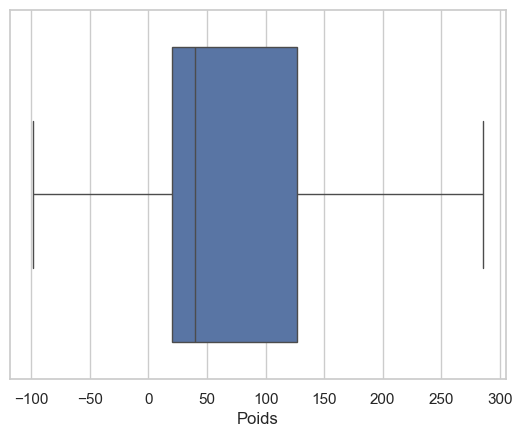

In [43]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Poids'] ,orient='h')

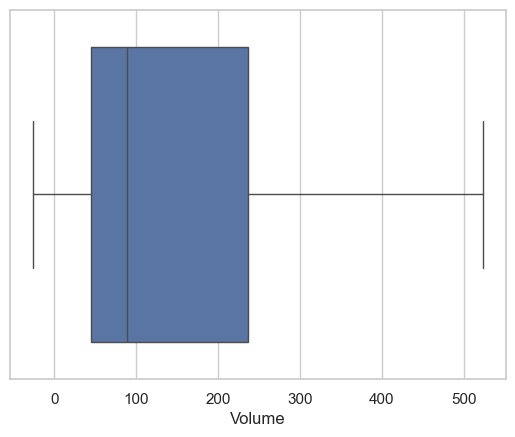

In [44]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Volume'] ,orient='h')

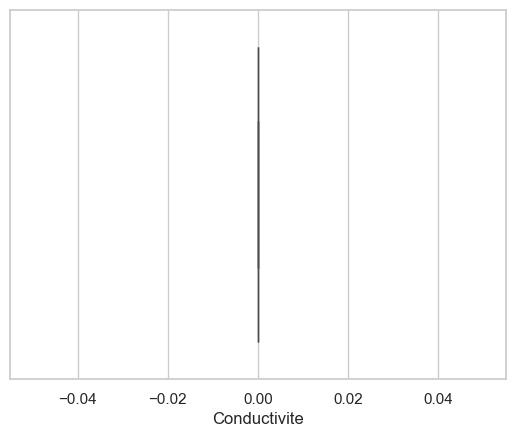

In [45]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Conductivite'] ,orient='h')

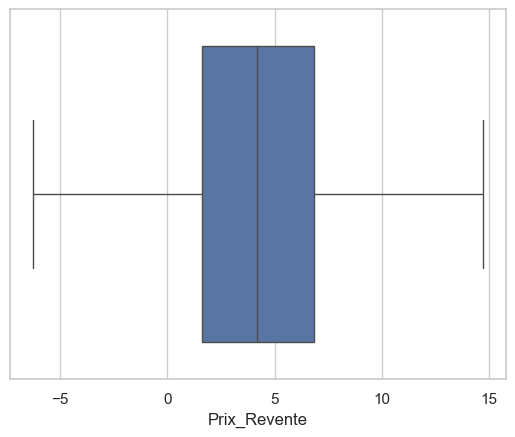

In [46]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Prix_Revente'] ,orient='h')

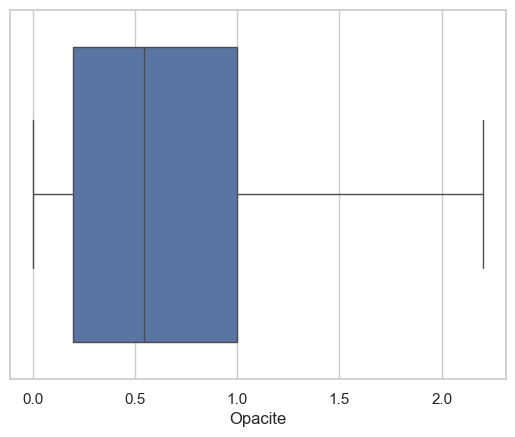

In [47]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Opacite'] ,orient='h')

- relation entre rigidité et volume

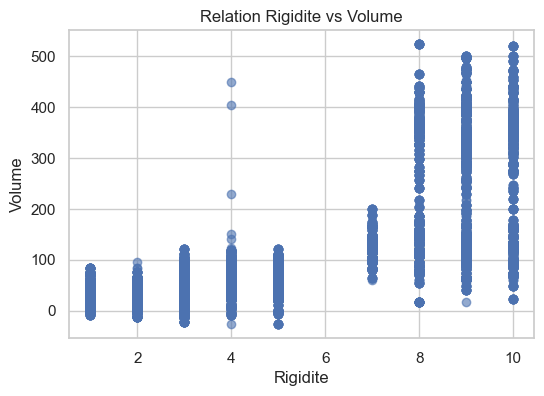

In [48]:
plt.figure(figsize=(6,4))
plt.scatter(df['Rigidite'], df['Volume'], alpha=0.6)
plt.xlabel('Rigidite')
plt.ylabel('Volume')
plt.title('Relation Rigidite vs Volume')
plt.show()

# Plus la rigidité augmente
# plus le volume est élevé 


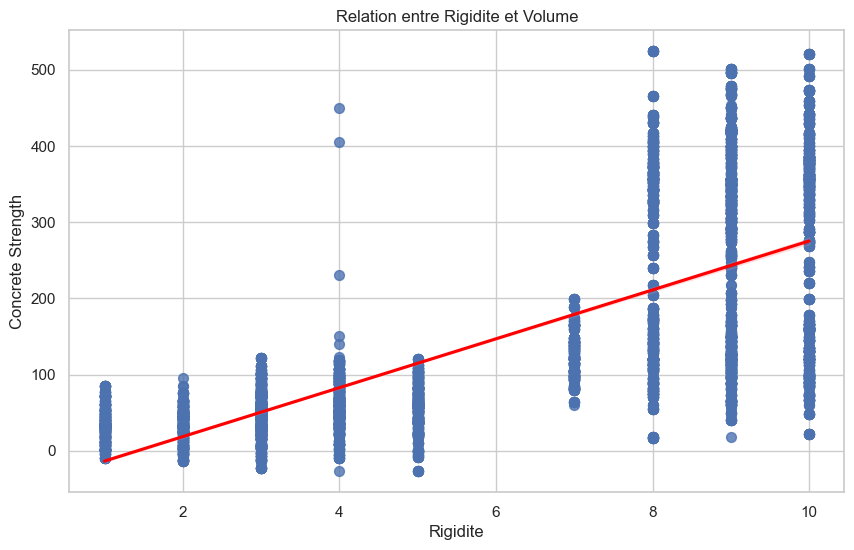

In [49]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Rigidite', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre Rigidite et Volume')
plt.xlabel('Rigidite')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

-  relation entre Poids et volume

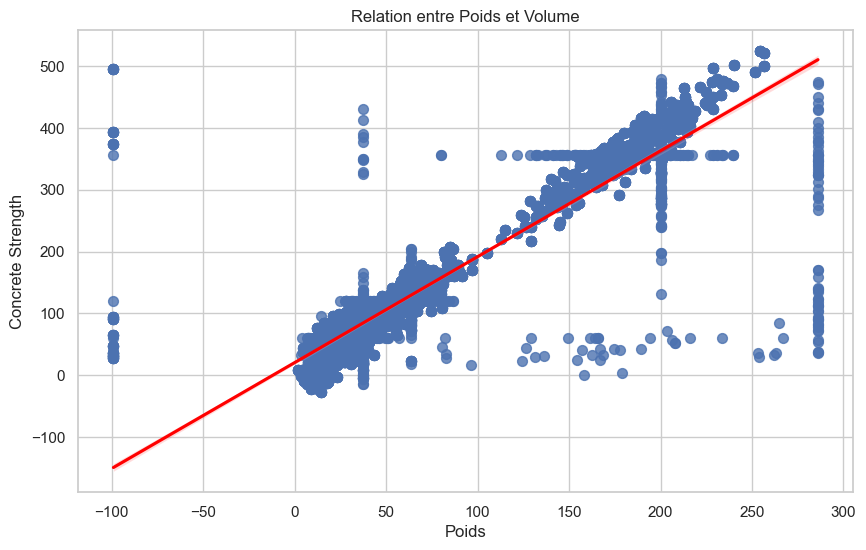

In [50]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Poids', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre Poids et Volume')
plt.xlabel('Poids')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

- Les Relations entre les variables avec pairplot

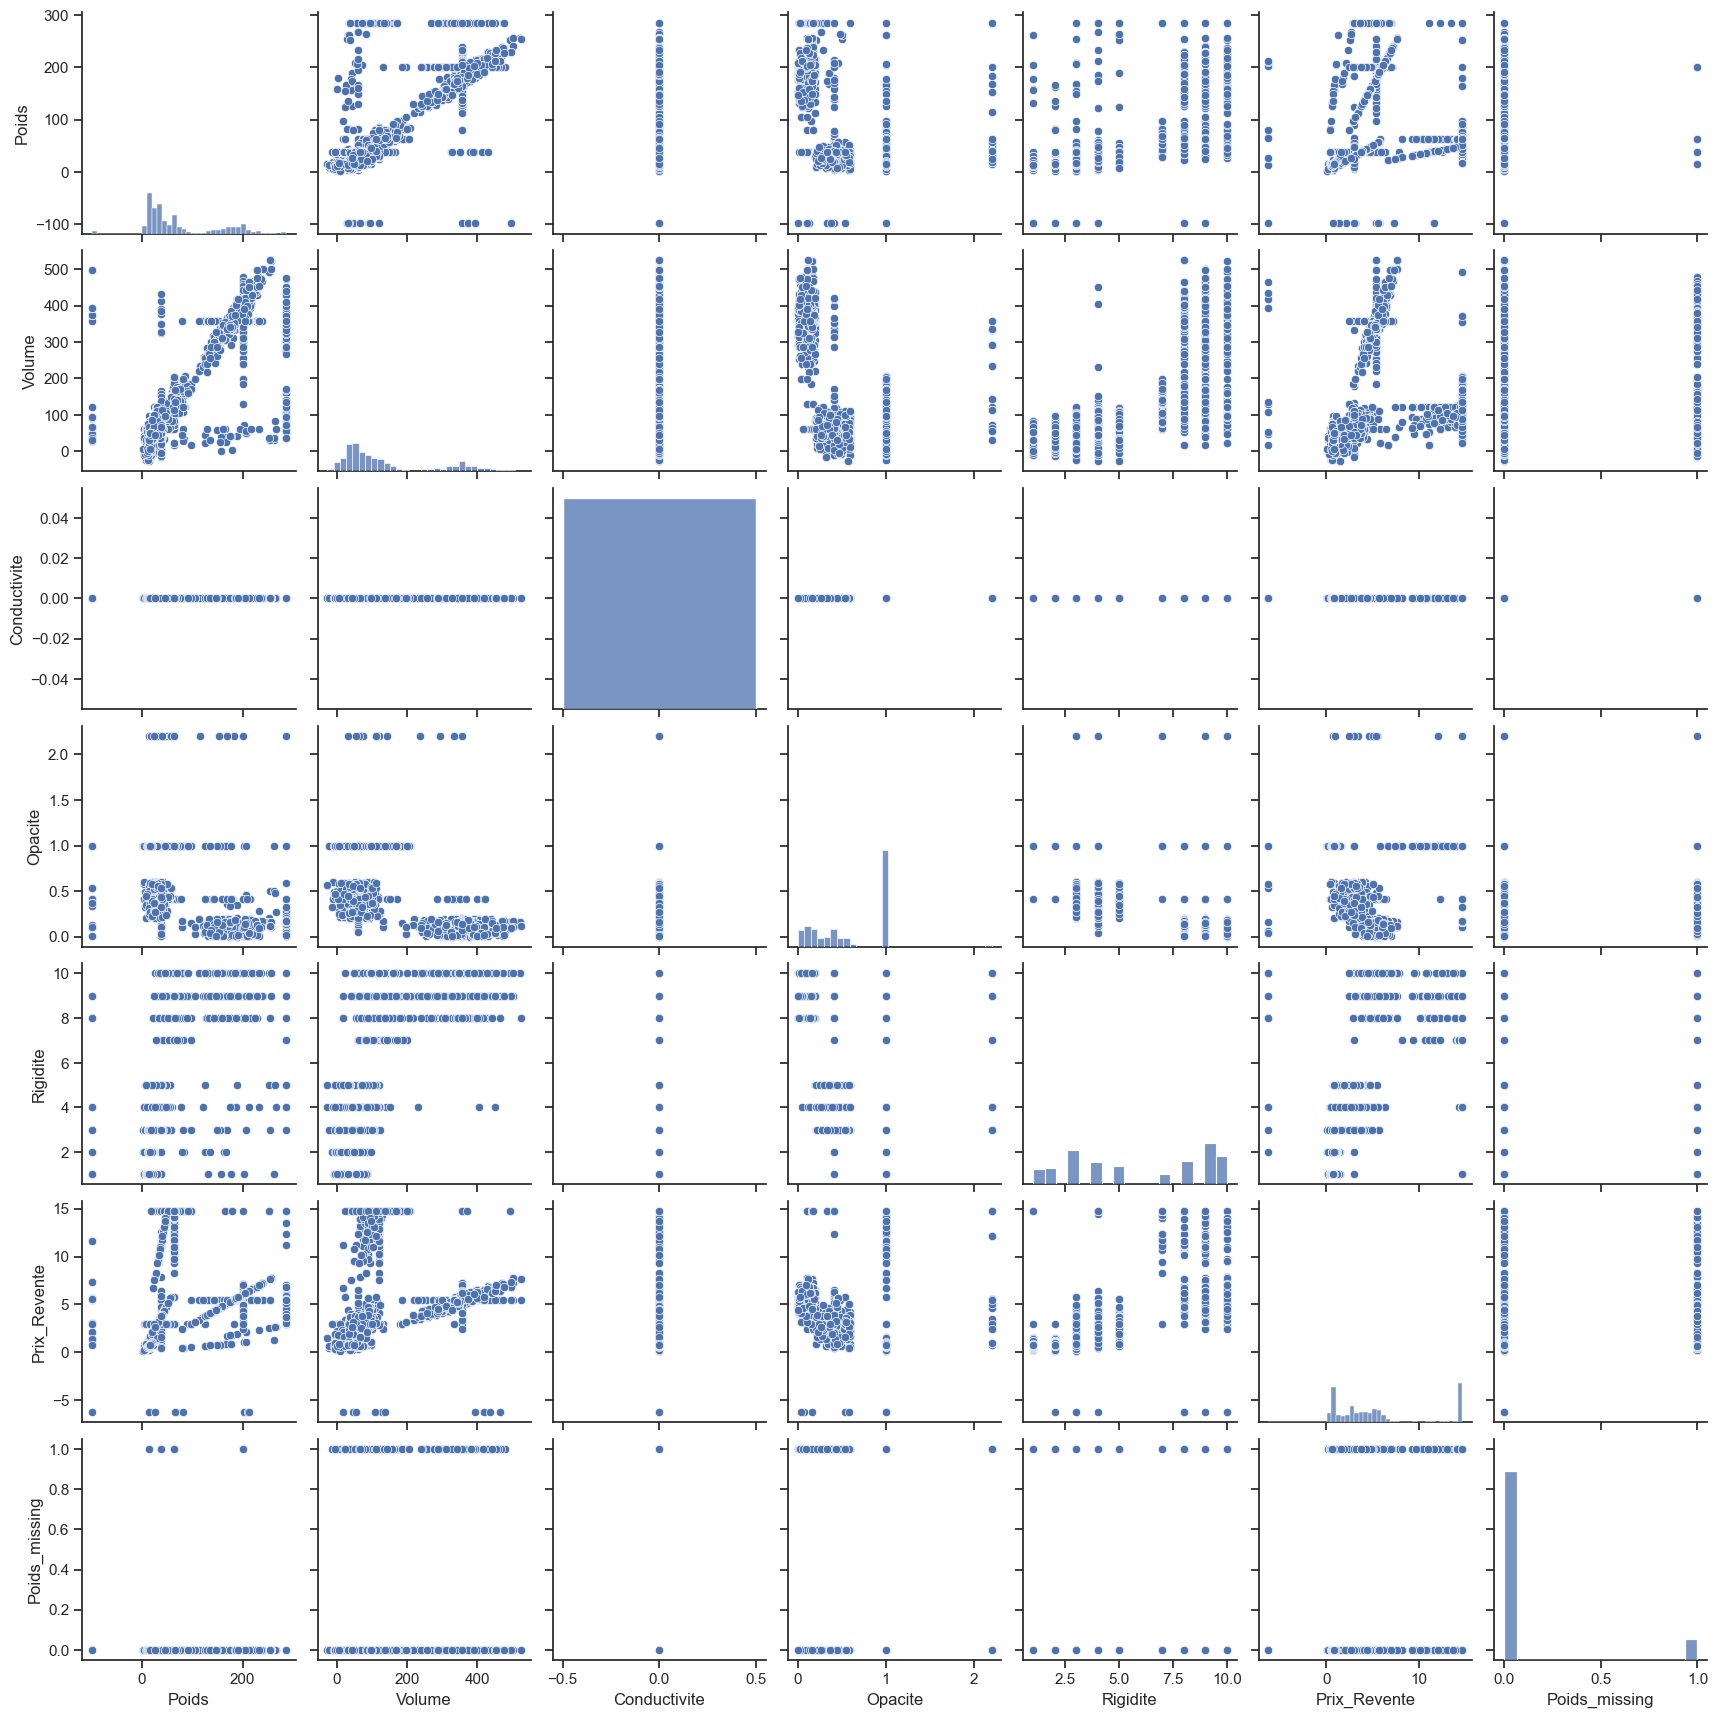

In [51]:
sns.set(style='ticks')
sns.pairplot(df)

### Etape 14 : Séparation des variables

- Pour Classification

In [52]:
Y_class = df['Categorie']
X_class = df.drop(['Categorie', 'Rapport_Collecte','Poids_missing'], axis=1)  # garde le DataFrame (pas .values)
print("Cible Y :")
print(Y_class)
print("\nEntrées X :")
print(X_class)

Cible Y :
0          Papier
1       Plastique
2           Verre
3          Papier
4          Papier
          ...    
9719        Verre
9720        Verre
9721       Papier
9722    Plastique
9723        Verre
Name: Categorie, Length: 9724, dtype: object

Entrées X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0      16.708780   70.940977           0.0  1.000000       1.0      0.835439   
1      47.277476   64.702925           0.0  0.412743       3.0      4.727748   
2     200.203552  317.415183           0.0  0.105535       9.0      4.211790   
3      14.664058   21.474391           0.0  1.000000       1.0      0.442067   
4      14.664058   59.462176           0.0  1.000000       2.0      0.723004   
...          ...         ...           ...       ...       ...           ...   
9719  191.018619  418.800912           0.0  0.019307       9.0      5.730559   
9720  149.052713  287.519460           0.0  0.157940      10.0      4.471581   
9721   15.5726

- Pour Regression

In [53]:
X_regg = df.drop(["Prix_Revente", "Rapport_Collecte","Poids_missing"], axis=1)
Y_regg = df["Prix_Revente"]
print("Cible Y :")
print(Y_regg)
print("\nEntrées X :")
print(X_regg)

Cible Y :
0       0.835439
1       4.727748
2       4.211790
3       0.442067
4       0.723004
          ...   
9719    5.730559
9720    4.471581
9721    0.778633
9722    2.670726
9723    4.400482
Name: Prix_Revente, Length: 9724, dtype: float64

Entrées X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
0      16.708780   70.940977           0.0  1.000000       1.0     Papier   
1      47.277476   64.702925           0.0  0.412743       3.0  Plastique   
2     200.203552  317.415183           0.0  0.105535       9.0      Verre   
3      14.664058   21.474391           0.0  1.000000       1.0     Papier   
4      14.664058   59.462176           0.0  1.000000       2.0     Papier   
...          ...         ...           ...       ...       ...        ...   
9719  191.018619  418.800912           0.0  0.019307       9.0      Verre   
9720  149.052713  287.519460           0.0  0.157940      10.0      Verre   
9721   15.572667   50.148243           0.0  1.00

In [54]:
print(type(X_regg))
print(X_regg.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie',
       'Source'],
      dtype='object')


### 15- afficher un echontillion de X et Y

In [55]:
print('Echantillon de X :')
print(X_class.iloc[np.random.choice(len(X_class), 5)])
print('\nEchantillon de Y :')
print(Y_class.iloc[np.random.choice(len(Y_class), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
1422  228.461271  356.731790           0.0  0.130230       9.0      6.853838   
1495  141.958934  286.384449           0.0  0.049381      10.0      4.258768   
194    23.132597   -3.360705           0.0  1.000000       3.0      0.740851   
3506   57.362184  147.953771           0.0  1.000000       8.0     14.740230   
2995   14.960137   59.519156           0.0  1.000000       3.0      0.748007   

                  Source  
1422          Centre_Tri  
1495             Usine_B  
194   Collecte_Citoyenne  
3506  Collecte_Citoyenne  
2995  Collecte_Citoyenne  

Echantillon de Y :
1800        Verre
7217    Plastique
3093       Papier
1759    Plastique
4175    Plastique
Name: Categorie, dtype: object


In [56]:
print('Echantillon de X :')
print(X_regg.iloc[np.random.choice(len(X_regg), 5)])
print('\nEchantillon de Y :')
print(Y_regg.iloc[np.random.choice(len(Y_regg), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
8258   25.127971   43.217515           0.0  0.302585       3.0  Plastique   
3816   62.126781  114.175173           0.0  1.000000       9.0      Métal   
7952  191.018619  418.800912           0.0  0.019307       9.0      Verre   
6990   12.240709   75.645404           0.0  1.000000       2.0     Papier   
7708   64.287981  135.265098           0.0  1.000000       7.0      Métal   

                  Source  
8258             Usine_A  
3816             Usine_A  
7952             Usine_B  
6990  Collecte_Citoyenne  
7708  Collecte_Citoyenne  

Echantillon de Y :
1172     0.517933
5045     2.742623
2979    14.740230
753     14.740230
9157     3.328760
Name: Prix_Revente, dtype: float64


### Etape 15 : categorisation

In [57]:
# Encoder la cible Y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_class = le.fit_transform(Y_class.astype(str))  # astype(str) gère les NaN

In [58]:
print(Y_class)

[1 2 3 ... 1 2 3]


In [59]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Trouver l'index de 'Source' dans X_class
source_idx = X_class.columns.get_loc('Source')

ct = ColumnTransformer(
    [('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [source_idx])],
    remainder='passthrough'
)
X_class = ct.fit_transform(X_class)

In [60]:
print(X_class)

[[0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 1.00000000e+00
  1.00000000e+00 8.35438994e-01]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 ... 4.12742992e-01
  3.00000000e+00 4.72774763e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.05535493e-01
  9.00000000e+00 4.21179011e+00]
 ...
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 1.00000000e+00
  2.00000000e+00 7.78633342e-01]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 2.66208204e-01
  4.00000000e+00 2.67072629e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 5.07727113e-03
  9.00000000e+00 4.40048174e+00]]


In [61]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Source']),
        ('Categorie', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Categorie'])
    ],
    remainder='passthrough'
)


X_regg = ct.fit_transform(X_regg)

In [62]:
print(X_regg)

[[0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 1.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 ... 0.00000000e+00
  4.12742992e-01 3.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.05535493e-01 9.00000000e+00]
 ...
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 2.00000000e+00]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  2.66208204e-01 4.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  5.07727113e-03 9.00000000e+00]]


### Etape 16 : Transformer X et Y en tableau numpy

- Classification

In [63]:
X_class = np.array(X_class, dtype=float)
Y_class = np.array(Y_class)


print("Shape de X après encodage :", X_class.shape)
print("Shape de Y :", Y_class.shape)

Shape de X après encodage : (9724, 10)
Shape de Y : (9724,)


- Regression

In [64]:
X_regg = np.array(X_regg, dtype=float)
Y_regg = np.array(Y_regg)

print("Shape de X après encodage :", X_regg.shape)
print("Shape de Y :", Y_regg.shape)

Shape de X après encodage : (9724, 13)
Shape de Y : (9724,)


- Vérifier cette transformation

In [65]:
X_class[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 8.35438994e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 4.12742992e-01,
        3.00000000e+00, 4.72774763e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        2.00203552e+02, 3.17415183e+02, 0.00000000e+00, 1.05535493e-01,
        9.00000000e+00, 4.21179011e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.46640579e+01, 2.14743907e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 4.42067308e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.46640579e+01, 5.94621756e+01, 0.00000000e+00, 1.00000000e+00,
        2.00000000e+00, 7.23003759e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
   

In [66]:
Y_class

array([1, 2, 3, ..., 1, 2, 3])

In [67]:
X_regg[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 4.12742992e-01,
        3.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        2.00203552e+02, 3.17415183e+02, 0.00000000e+00, 1.05535493e-01,
        9.00000000e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.46640579e+01, 2.14743907e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [0.00000000e+00, 0.00000000e+

In [68]:
Y_regg

array([0.83543899, 4.72774763, 4.21179011, ..., 0.77863334, 2.67072629,
       4.40048174])

### Etape 17 : Split

- Classification

In [69]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_class, Y_class, test_size=0.2, random_state=0
)

print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('y_train mean:', y_train.mean())
print('y_test mean:', y_test.mean())

x_train: (7779, 10)
x_test: (1945, 10)
y_train: (7779,)
y_test: (1945,)
y_train mean: 1.5836225735955778
y_test mean: 1.585089974293059


- Regression

In [70]:
from sklearn.model_selection import train_test_split
x_train_reg , x_test_reg ,y_train_reg ,y_test_reg =train_test_split(X_regg,Y_regg,test_size =0.2 ,random_state=0)
print('x_train:',x_train_reg.shape)
print('x_test:',x_test_reg.shape)
print('y_train:',y_train_reg.shape)
print('y_test:',y_test_reg.shape)
print('y_train:',y_train_reg.mean())
print('y_test:',y_test_reg.mean())

x_train: (7779, 13)
x_test: (1945, 13)
y_train: (7779,)
y_test: (1945,)
y_train: 5.713406541822654
y_test: 5.574806665968859


### Etape 18 : Standarisation

- Classification

In [71]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [72]:
print(x_train[:5])

[[ 1.82782926 -0.66273897 -0.56829498 -0.53160616 -0.70058192 -0.72108679
   0.          0.92193881 -0.95705014 -0.91171133]
 [-0.54709705  1.50888969 -0.56829498 -0.53160616  1.09480201  1.06104672
   0.         -1.11224324  0.98932713 -0.23190481]
 [-0.54709705 -0.66273897  1.75964954 -0.53160616  1.17885468  1.24322336
   0.         -1.45679699  0.98932713 -0.19595426]
 [-0.54709705 -0.66273897 -0.56829498  1.88109182  1.38502014  1.43272663
   0.         -1.01246445  0.98932713 -0.10777429]
 [-0.54709705 -0.66273897  1.75964954 -0.53160616 -0.4220658  -0.62483196
   0.         -0.04442682 -0.63265393 -0.29436331]]


- Regression

In [73]:
from sklearn.preprocessing import StandardScaler
sc1 = StandardScaler()
x_train_reg = sc1.fit_transform(x_train_reg)
x_test_reg = sc1.transform(x_test_reg)

In [74]:
print(x_train_reg[:5])

[[ 1.82782926 -0.66273897 -0.56829498 -0.53160616 -0.53737082  1.90534961
  -0.67380909 -0.5738372  -0.70058192 -0.72108679  0.          0.92193881
  -0.95705014]
 [-0.54709705  1.50888969 -0.56829498 -0.53160616 -0.53737082 -0.52483806
  -0.67380909  1.74265454  1.09480201  1.06104672  0.         -1.11224324
   0.98932713]
 [-0.54709705 -0.66273897  1.75964954 -0.53160616 -0.53737082 -0.52483806
  -0.67380909  1.74265454  1.17885468  1.24322336  0.         -1.45679699
   0.98932713]
 [-0.54709705 -0.66273897 -0.56829498  1.88109182 -0.53737082 -0.52483806
  -0.67380909  1.74265454  1.38502014  1.43272663  0.         -1.01246445
   0.98932713]
 [-0.54709705 -0.66273897  1.75964954 -0.53160616 -0.53737082 -0.52483806
   1.48409989 -0.5738372  -0.4220658  -0.62483196  0.         -0.04442682
  -0.63265393]]


# Classification

## * Modélisation KNN et évaluation

Il faut imputer les valeurs manquantes avant le fit. 

In [75]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score,f1_score, classification_report
import numpy as np


# --- Entraînement du modèle KNN ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

# --- Prédictions ---
y_pred_knn = knn.predict(x_test)

# --- Conversion en entiers ---
y_test_eval = np.array(y_test).astype(int)
y_pred_knn  = np.array(y_pred_knn).astype(int)

# --- Évaluation ---
print('\nConfusion Matrix:\n', confusion_matrix(y_test_eval, y_pred_knn))
print(f'\nAccuracy  : {accuracy_score(y_test_eval, y_pred_knn):.4f}')
print(f'Recall    : {recall_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print(f'Precision : {precision_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print(f'f1-score : {f1_score(y_test, y_pred_knn, average='macro'):.4f}')
print('\nClassification Report:\n', classification_report(y_test_eval, y_pred_knn))




Confusion Matrix:
 [[418   0   2   0]
 [  0 421   3   0]
 [ 20  26 570  28]
 [  0   0   4 453]]

Accuracy  : 0.9573
Recall    : 0.9661
Precision : 0.9556
f1-score : 0.9598

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       420
           1       0.94      0.99      0.97       424
           2       0.98      0.89      0.93       644
           3       0.94      0.99      0.97       457

    accuracy                           0.96      1945
   macro avg       0.96      0.97      0.96      1945
weighted avg       0.96      0.96      0.96      1945



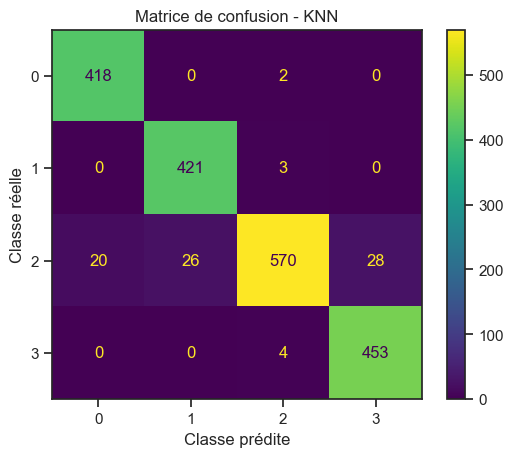

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matrice de confusion
cm = confusion_matrix(y_test_eval, y_pred_knn)

# Affichage graphique
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - KNN")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

La matrice de confusion montre que le modèle KNN obtient de très bonnes performances, avec une majorité de prédictions correctes visibles sur la diagonale principale. Les erreurs de classification sont faibles, ce qui indique une bonne capacité du modèle à distinguer les différentes classes.


# Mdélisation Grid Search et évaluation

problème multiclasse, donc il faut average='macro'

In [77]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13]}
model = KNeighborsClassifier()

clf = GridSearchCV(model, parameters, scoring='recall_macro', cv=5)
grille = clf.fit(x_train, y_train)

print("Meilleur paramètre :", grille.best_params_)
print("Meilleur score     :", grille.best_score_)

y_pred_knn_o = grille.predict(x_test)

knn_op_acc  = accuracy_score(y_test, y_pred_knn_o)
knn_op_rec  = recall_score(y_test, y_pred_knn_o, average='macro')
knn_op_prec = precision_score(y_test, y_pred_knn_o, average='macro')
knn_op_f1 = f1_score(y_test, y_pred_knn_o, average='macro')

print('\nConfusion Matrix KNN optimisé:\n', confusion_matrix(y_test, y_pred_knn_o))
print(f'Accuracy  : {knn_op_acc:.4f}')
print(f'Recall    : {knn_op_rec:.4f}')
print(f'Precision : {knn_op_prec:.4f}')
print(f'F1 - score : {knn_op_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_knn_o))

Meilleur paramètre : {'n_neighbors': 5}
Meilleur score     : 0.9702075087363135

Confusion Matrix KNN optimisé:
 [[419   0   1   0]
 [  0 420   4   0]
 [ 20  27 567  30]
 [  0   0   0 457]]
Accuracy  : 0.9578
Recall    : 0.9672
Precision : 0.9559
F1 - score : 0.9602

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       420
           1       0.94      0.99      0.96       424
           2       0.99      0.88      0.93       644
           3       0.94      1.00      0.97       457

    accuracy                           0.96      1945
   macro avg       0.96      0.97      0.96      1945
weighted avg       0.96      0.96      0.96      1945



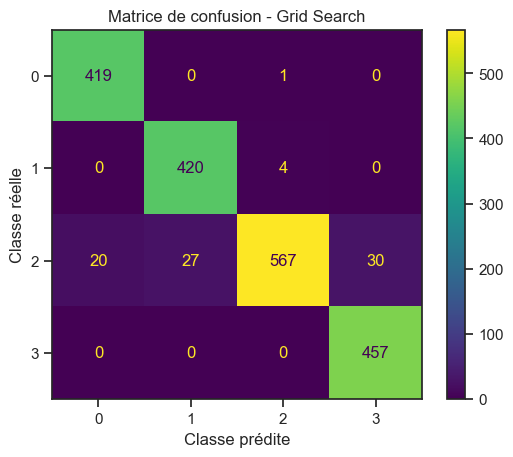

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_pred_knn_o)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Grid Search")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

La matrice de confusion après l’utilisation de Grid Search permet d’évaluer le modèle optimisé avec les meilleurs hyperparamètres afin de vérifier l’amélioration des performances de classification.

# Decision Tree

In [79]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=0)
dt.fit(x_train, y_train)

# --- Prédictions ---
y_pred_dt = dt.predict(x_test)

# --- Évaluation ---
accur_dt = accuracy_score(y_test, y_pred_dt)
rec_dt   = recall_score(y_test, y_pred_dt, average='macro')
pres_dt  = precision_score(y_test, y_pred_dt, average='macro')
dt_f1    = f1_score(y_test, y_pred_dt, average='macro')

print('Confusion Matrix DT:\n', confusion_matrix(y_test, y_pred_dt))
print(f'Accuracy  : {accur_dt:.4f}')
print(f'Recall    : {rec_dt:.4f}')
print(f'Precision : {pres_dt:.4f}')
print(f'Score-F1 : {dt_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_dt))

Confusion Matrix DT:
 [[418   0   2   0]
 [  0 424   0   0]
 [ 18  27 579  20]
 [  0   0   0 457]]
Accuracy  : 0.9656
Recall    : 0.9736
Precision : 0.9634
Score-F1 : 0.9674

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       420
           1       0.94      1.00      0.97       424
           2       1.00      0.90      0.95       644
           3       0.96      1.00      0.98       457

    accuracy                           0.97      1945
   macro avg       0.96      0.97      0.97      1945
weighted avg       0.97      0.97      0.97      1945



Confusion Matrix DT:


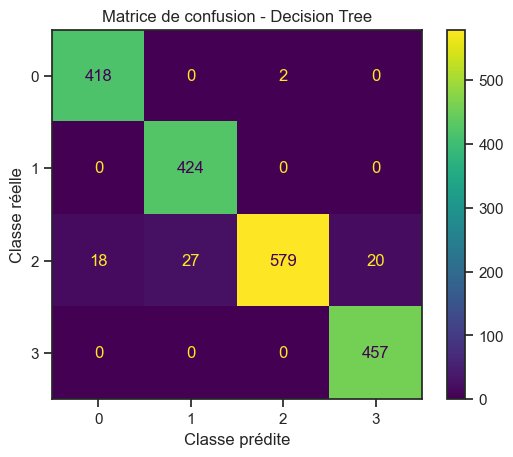

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Decision Tree")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()


La matrice de confusion du modèle Decision Tree permet de visualiser les prédictions correctes et les erreurs de classification afin d’évaluer les performances de l’arbre de décision.

## Importance des features

# Random Forest

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=0)
rf.fit(x_train, y_train)

# --- Prédictions ---
y_pred_rf = rf.predict(x_test)

# --- Évaluation ---
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_rec  = recall_score(y_test, y_pred_rf, average='macro')
rf_prec = precision_score(y_test, y_pred_rf, average='macro')
rf_f1     = f1_score(y_test, y_pred_rf, average='macro')

print('Confusion Matrix RF:\n', confusion_matrix(y_test, y_pred_rf))
print(f'Accuracy  : {rf_acc:.4f}')
print(f'Recall    : {rf_rec:.4f}')
print(f'Precision : {rf_prec:.4f}')
print(f'Score-F1 : {rf_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

Confusion Matrix RF:
 [[418   0   2   0]
 [  0 424   0   0]
 [ 17  24 583  20]
 [  0   0   1 456]]
Accuracy  : 0.9671
Recall    : 0.9746
Precision : 0.9651
Score-F1 : 0.9689

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       420
           1       0.95      1.00      0.97       424
           2       0.99      0.91      0.95       644
           3       0.96      1.00      0.98       457

    accuracy                           0.97      1945
   macro avg       0.97      0.97      0.97      1945
weighted avg       0.97      0.97      0.97      1945



Confusion Matrix RF:


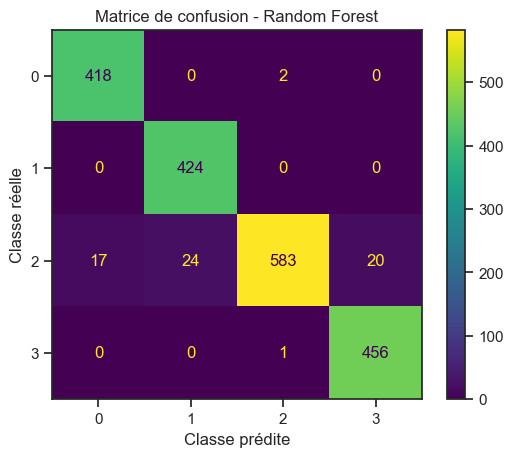

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

Cette matrice de confusion montre la qualité des prédictions du modèle Random Forest et permet d’analyser les classes correctement reconnues ainsi que les erreurs éventuelles.

Feature Importance : Random Forest

SHAP Summary Plot

SHAP Bar Plot

les 3 graphiques obligatoires
Graphique Feature Importance (importance des variables avec Random Forest)
Graphique SHAP Summary Plot (le plus important)
Graphique SHAP Bar Plot (les features les plus importantes)

# SVM linéaire

In [83]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# === Ton code original (corrigé seulement le strict minimum) ===
linear_SVM = SVC(kernel='linear')
linear_SVM.fit(x_train, y_train)
y_predictSVM_l = linear_SVM.predict(x_test)

svm_acc  = accuracy_score(y_test, y_predictSVM_l)
svm_prec = precision_score(y_test, y_predictSVM_l, average='macro')
svm_rec  = recall_score(y_test, y_predictSVM_l, average='macro')
svm_f1    = f1_score(y_test, y_predictSVM_l, average='macro')

print(confusion_matrix(y_test, y_predictSVM_l))
print('Accuracy linear SVM {0:.3f}'.format(svm_acc))
print('Precision linear SVM {0:.3f}'.format(svm_prec))
print('Recall linear SVM {0:.3f}'.format(svm_rec))
print(f'Score-F1 : {svm_rec:.4f}')
print(classification_report(y_test, y_predictSVM_l))

[[418   0   0   2]
 [  0 423   1   0]
 [ 27  33 558  26]
 [  0   0   3 454]]
Accuracy linear SVM 0.953
Precision linear SVM 0.950
Recall linear SVM 0.963
Score-F1 : 0.9632
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       420
           1       0.93      1.00      0.96       424
           2       0.99      0.87      0.93       644
           3       0.94      0.99      0.97       457

    accuracy                           0.95      1945
   macro avg       0.95      0.96      0.96      1945
weighted avg       0.96      0.95      0.95      1945



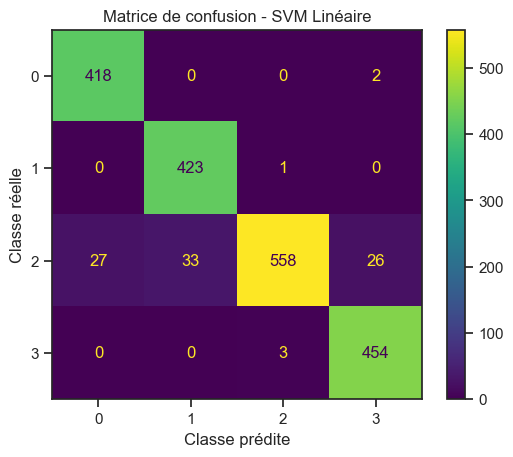

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_predictSVM_l)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - SVM Linéaire")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

La matrice de confusion du SVM linéaire permet de mesurer l’efficacité du modèle dans la séparation des différentes classes et d’identifier les erreurs de classification.

# Logistic Regression

In [85]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [86]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

y_predictLR = LR.predict(x_test)

LR_acc  = accuracy_score(y_test, y_predictLR)
LR_prec = metrics.precision_score(y_test, y_predictLR, average='macro')   # ← corrigé multi-classes
LR_rec  = metrics.recall_score(y_test, y_predictLR, average='macro')      # ← corrigé multi-classes
LR_f1     = f1_score(y_test,  y_predictLR, average='macro')  # si Logistic Regression existefrom sklearn.metrics import f1_score

print(confusion_matrix(y_test, y_predictLR))
print('Accuracy Logistic Regression {0:.3f}'.format(LR_acc))
print('Precision Logistic Regression {0:.3f}'.format(LR_prec))
print('Recall Logistic Regression {0:.3f}'.format(LR_rec))
print('F1-Score Logistic Regression {0:.3f}'.format(LR_f1))
print(classification_report(y_test, y_predictLR))

[[418   0   0   2]
 [  0 423   1   0]
 [ 20  33 564  27]
 [  0   0   1 456]]
Accuracy Logistic Regression 0.957
Precision Logistic Regression 0.955
Recall Logistic Regression 0.967
F1-Score Logistic Regression 0.959
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       420
           1       0.93      1.00      0.96       424
           2       1.00      0.88      0.93       644
           3       0.94      1.00      0.97       457

    accuracy                           0.96      1945
   macro avg       0.95      0.97      0.96      1945
weighted avg       0.96      0.96      0.96      1945



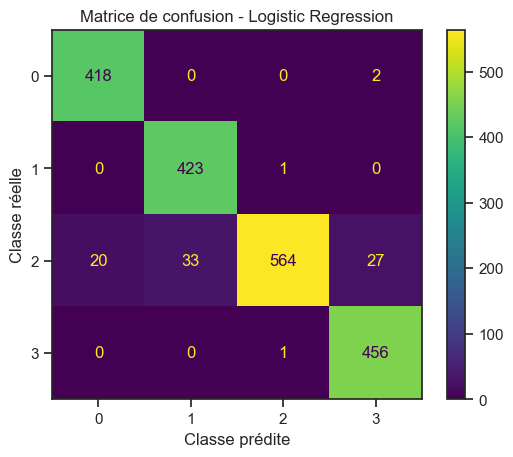

In [87]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_predictLR)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Logistic Regression")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

- Courbe ROC=Receiver Operating Characteristic

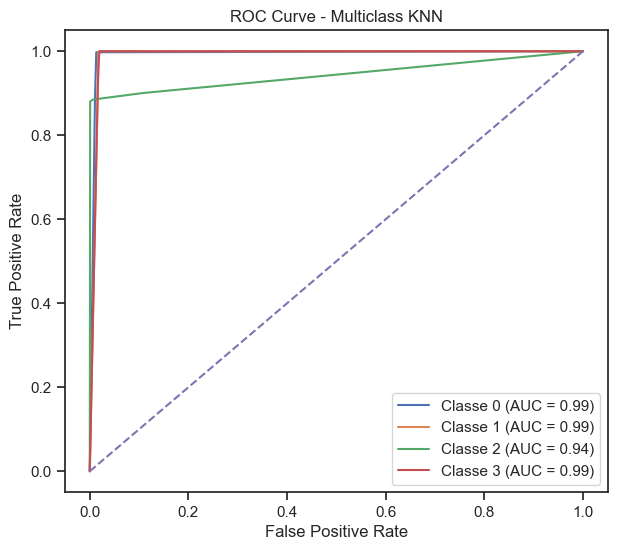

In [88]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)

# probabilités du modèle
y_score = knn.predict_proba(x_test)


plt.figure(figsize=(7,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Classe {classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multiclass KNN")

plt.legend()
plt.show()

La courbe ROC aide à voir si le modèle distingue bien les classes. Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle.

# Sommary

In [89]:
print("| Algorithm         | Accuracy   | Recall     | Precision  | F1-score ")
print("| ----------------- | ---------- | ---------- | ---------- |----------")
print("| Optimized kNN     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(knn_op_acc, knn_op_rec, knn_op_prec , knn_op_f1))
print("| Decision Tree     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(accur_dt, rec_dt, pres_dt,dt_f1))
print("| Random Forest     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(rf_acc, rf_rec, rf_prec,rf_f1,))
print("| Linear SVM        | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(svm_acc, svm_rec, svm_prec,svm_rec))
print("| Logistic Reg      | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f}".format(LR_acc, LR_rec, LR_prec,LR_f1))

| Algorithm         | Accuracy   | Recall     | Precision  | F1-score 
| ----------------- | ---------- | ---------- | ---------- |----------
| Optimized kNN     | 0.95784    | 0.96715    | 0.95592    |0.96019 
| Decision Tree     | 0.96555    | 0.97358    | 0.96337    |0.96742 
| Random Forest     | 0.96710    | 0.97458    | 0.96505    |0.96893 
| Linear SVM        | 0.95270    | 0.96319    | 0.95044    |0.96319 
| Logistic Reg      | 0.95681    | 0.96662    | 0.95466    |0.95903


# Regression

# Régression linéaire

In [90]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np
import pandas as pd

linear_model = LinearRegression()
linear_model.fit(x_train_reg, y_train_reg)

y_pred_lr = linear_model.predict(x_test_reg)

r2_lr = r2_score(y_test_reg, y_pred_lr)
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mape_lr = mean_absolute_percentage_error(y_test_reg, y_pred_lr)
medae_lr = median_absolute_error(y_test_reg, y_pred_lr)

print("===== Régression Linéaire =====")
print("R2    :", r2_lr)
print("MAE   :", mae_lr)
print("MSE   :", mse_lr)
print("RMSE  :", rmse_lr)
print("MAPE  :", mape_lr)
print("MEDAE :", medae_lr)

results_lr = pd.DataFrame(x_test_reg)
results_lr["prix_reel"] = y_test_reg
results_lr["prix_predit"] = y_pred_lr

print(results_lr.head())

===== Régression Linéaire =====
R2    : 0.8748047119489959
MAE   : 0.8773758293971696
MSE   : 3.167376415299207
RMSE  : 1.7797124529819999
MAPE  : 0.3228288423585603
MEDAE : 0.45021124032784954
          0         1         2         3         4         5         6  \
0 -0.547097 -0.662739 -0.568295  1.881092 -0.537371 -0.524838  1.484100   
1 -0.547097 -0.662739  1.759650 -0.531606 -0.537371 -0.524838 -0.673809   
2  1.827829 -0.662739 -0.568295 -0.531606  1.860912 -0.524838 -0.673809   
3 -0.547097 -0.662739  1.759650 -0.531606 -0.537371 -0.524838  1.484100   
4 -0.547097  1.508890 -0.568295 -0.531606 -0.537371 -0.524838 -0.673809   

          7         8         9   10        11        12  prix_reel  \
0 -0.573837 -0.533683 -0.589731  0.0 -0.120717 -0.632654   3.424473   
1  1.742655  1.441680  1.530709  0.0 -1.450171  1.313723   5.291756   
2 -0.573837 -0.125053 -0.069688  0.0  0.921939  0.989327  14.740230   
3 -0.573837  1.624029 -0.757715  0.0 -0.639690 -0.308258   1.895137   


# Régression Ridge/Lasso (avec régularisation)


- Ridge

In [91]:
from sklearn.linear_model import Ridge
# création du modèle
ridge_model = Ridge(alpha=1.0)
# entraînement
ridge_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_ridge = ridge_model.predict(x_test_reg)

In [92]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
import numpy as np
r2_ridge = r2_score(y_test_reg, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mape_ridge = mean_absolute_percentage_error(y_test_reg, y_pred_ridge)
medae_ridge = median_absolute_error(y_test_reg, y_pred_ridge)
print("Ridge Regression")
print("R2 :", r2_ridge)
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE :", rmse_ridge)
print("MAPE :", mape_ridge)
print("MEDAE :",medae_ridge)

Ridge Regression
R2 : 0.8748234448710231
MAE : 0.8787970759106597
MSE : 3.166902482003932
RMSE : 1.779579299161443
MAPE : 0.32355393127049653
MEDAE : 0.4490831555575303


- Lasso

In [93]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
# création du modèle
lasso_model = Lasso(alpha=0.1)
# entraînement
lasso_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_lasso = lasso_model.predict(x_test_reg)

In [94]:
r2_lasso = r2_score(y_test_reg, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test_reg, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mape_lasso = mean_absolute_percentage_error(y_test_reg, y_pred_lasso)
medae_lasso = median_absolute_error(y_test_reg, y_pred_lasso)
print("Lasso Regression")
print("R2 :", r2_lasso)
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE :", rmse_lasso)
print("MAPE :",mape_lasso)
print("MEDAE :",medae_lasso)

Lasso Regression
R2 : 0.8669077117323681
MAE : 0.935671975166693
MSE : 3.367166460333243
RMSE : 1.834984049067796
MAPE : 0.34457408811567936
MEDAE : 0.5653554913099086


# ElasticNet

In [95]:
from sklearn.linear_model import ElasticNet
# création du modèle
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
# entraînement
elastic_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_elastic = elastic_model.predict(x_test_reg)


In [96]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
import numpy as np
r2_elastic = r2_score(y_test_reg, y_pred_elastic)
mae_elastic = mean_absolute_error(y_test_reg, y_pred_elastic)
mse_elastic = mean_squared_error(y_test_reg, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
print("ElasticNet Regression")
print("R2 :", r2_elastic)
print("MAE :", mae_elastic)
print("MSE :", mse_elastic)
print("RMSE :", rmse_elastic)

ElasticNet Regression
R2 : 0.8687962593331127
MAE : 0.9877634415993622
MSE : 3.319387177079938
RMSE : 1.8219185429321307


# Régression polynomiale

In [97]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])
poly_model.fit(x_train_reg, y_train_reg)
y_pred_poly = poly_model.predict(x_test_reg)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
r2_poly = r2_score(y_test_reg, y_pred_poly)
mae_poly = mean_absolute_error(y_test_reg, y_pred_poly)
mse_poly = mean_squared_error(y_test_reg, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mape_poly = mean_absolute_percentage_error(y_test_reg, y_pred_poly)
medae_poly = median_absolute_error(y_test_reg, y_pred_poly)
print("Polynomial Regression")
print("R2 :", r2_poly)
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE :", rmse_poly)
print("MAPE :",mape_poly)
print("MEDAE :",medae_poly)

Polynomial Regression
R2 : 0.9049395850067644
MAE : 0.7368010381845704
MSE : 2.404979621561042
RMSE : 1.5507996716407448
MAPE : 0.23418406464678226
MEDAE : 0.4100664135508456


#  DecisionTreeRegressor

In [98]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
tree_model = DecisionTreeRegressor(max_depth=5)
tree_model.fit(x_train_reg, y_train_reg)
y_pred_tree = tree_model.predict(x_test_reg)
r2_tree = r2_score(y_test_reg, y_pred_tree)
mae_tree = mean_absolute_error(y_test_reg, y_pred_tree)
mse_tree = mean_squared_error(y_test_reg, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
mape_tree = mean_absolute_percentage_error(y_test_reg, y_pred_tree)
medae_tree = median_absolute_error(y_test_reg, y_pred_tree)
print("Decision Tree Regressor")
print("R2 :", r2_tree)
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE :", rmse_tree)
print("MAPE :",mape_tree)
print("MEDAE :",medae_tree)

Decision Tree Regressor
R2 : 0.9406087389247642
MAE : 0.44093533002956775
MSE : 1.5025683676524846
RMSE : 1.225792954643028
MAPE : 0.1723365687697509
MEDAE : 0.20681543526335844


#  RandomForestRegressor

In [99]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(x_train_reg, y_train_reg)
y_pred_rf = rf_model.predict(x_test_reg)
r2_rf = r2_score(y_test_reg, y_pred_rf)
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mape_rf = mean_absolute_percentage_error(y_test_reg, y_pred_rf)
medae_rf = median_absolute_error(y_test_reg, y_pred_rf)
print("Random Forest")
print("R2 :", r2_rf)
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("MAPE :",mape_rf)
print("MEDAE :",medae_rf)

Random Forest
R2 : 0.966048830109171
MAE : 0.20121406661535796
MSE : 0.858947141367002
RMSE : 0.9267940123711428
MAPE : 0.07045033408446497
MEDAE : 0.033227667315903986


# GradientBoostingRegressor


In [100]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)
gbr_model.fit(x_train_reg, y_train_reg)
y_pred_gbr = gbr_model.predict(x_test_reg)
r2_gbr = r2_score(y_test_reg, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test_reg, y_pred_gbr)
mse_gbr = mean_squared_error(y_test_reg, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mape_gbr = mean_absolute_percentage_error(y_test_reg, y_pred_gbr)
medae_gbr = median_absolute_error(y_test_reg, y_pred_gbr)
print("Gradient Boosting")
print("R2 :", r2_gbr)
print("MAE :", mae_gbr)
print("MSE :", mse_gbr)
print("RMSE :", rmse_gbr)
print("MAPE :",mape_gbr)
print("MEDAE :",medae_gbr)

Gradient Boosting
R2 : 0.9530668084184938
MAE : 0.3164219344466644
MSE : 1.1873856150993507
RMSE : 1.089672251229401
MAPE : 0.11127463590100138
MEDAE : 0.10822192607042957


# XGBoost

In [101]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)
xgb_model.fit(x_train_reg, y_train_reg)
y_pred_xgb = xgb_model.predict(x_test_reg)
r2_xgb = r2_score(y_test_reg, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)
mse_xgb = mean_squared_error(y_test_reg, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mape_xgb = mean_absolute_percentage_error(y_test_reg, y_pred_xgb)
medae_xgb = median_absolute_error(y_test_reg, y_pred_xgb)
print("XGBoost")
print("R2 :", r2_xgb)
print("RMSE :", rmse_xgb)
print("MAPE :",mape_xgb)
print("MEDAE :",medae_xgb)

XGBoost
R2 : 0.9635779401696205
RMSE : 0.9599267609384279
MAPE : 0.07229695828831091
MEDAE : 0.04234000460591236


# LightGBM

In [102]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    verbosity=-1
)
lgb_model.fit(x_train_reg, y_train_reg)
y_pred_lgb = lgb_model.predict(x_test_reg)
r2_lgb = r2_score(y_test_reg, y_pred_lgb)
mae_lgb = mean_absolute_error(y_test_reg, y_pred_lgb)
mse_lgb = mean_squared_error(y_test_reg, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
mape_lgb = mean_absolute_percentage_error(y_test_reg, y_pred_lgb)
medae_lgb = median_absolute_error(y_test_reg, y_pred_lgb)
print("LightGBM")
print("R2 :", r2_lgb)
print("RMSE :", rmse_lgb)
print("MAPE :",mape_lgb)
print("MEDAE :",medae_lgb)

LightGBM
R2 : 0.961942180144786
RMSE : 0.9812457765136036
MAPE : 0.08659663842323463
MEDAE : 0.06636818268417244


# CatBoost

In [103]:
# =========================================================
# 1. IMPORTS
# =========================================================
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
import pandas as pd
import shap

# =========================================================
# 2. TRAIN CATBOOST (BASELINE)
# =========================================================
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat_model.fit(x_train_reg, y_train_reg)
y_pred_cat = cat_model.predict(x_test_reg)

# Metrics AVANT SHAP
r2_cat = r2_score(y_test_reg, y_pred_cat)
mae_cat = mean_absolute_error(y_test_reg, y_pred_cat)
mse_cat = mean_squared_error(y_test_reg, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
mape_cat = mean_absolute_percentage_error(y_test_reg, y_pred_cat)
medae_cat = median_absolute_error(y_test_reg, y_pred_cat)

print("=== CatBoost AVANT SHAP ===")
print("R2 :", r2_cat)
print("RMSE :", rmse_cat)
print("MAPE :", mape_cat)
print("MEDAE :", medae_cat)



=== CatBoost AVANT SHAP ===
R2 : 0.9630507831459834
RMSE : 0.9668485858770041
MAPE : 0.07490785993116857
MEDAE : 0.05306206927496859


# SHAP

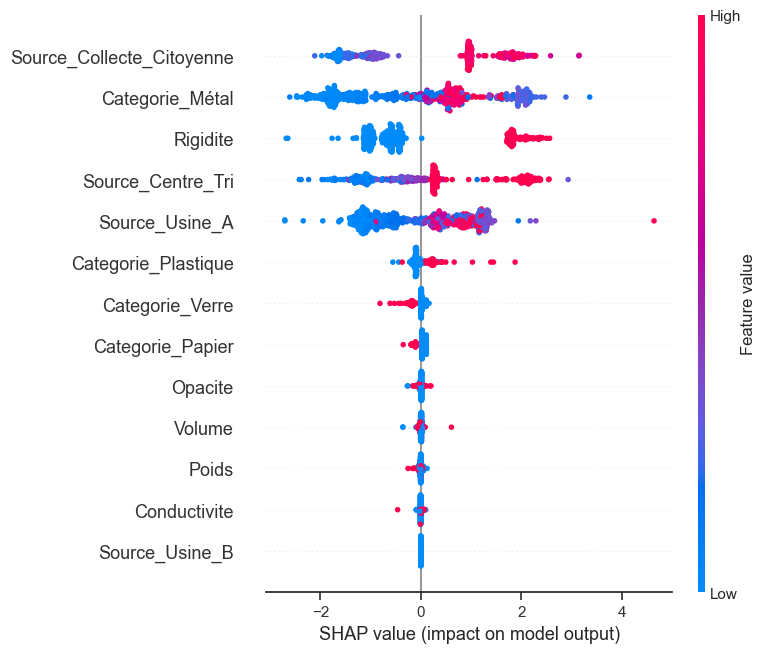

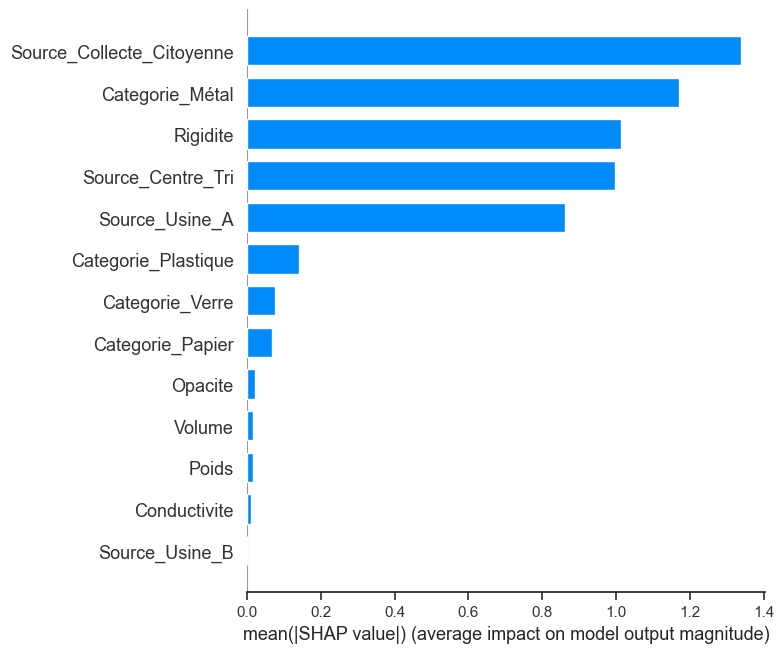


=== TOP 10 FEATURES ===
                      Feature  Importance_SHAP
12  Source_Collecte_Citoyenne          1.33745
8             Categorie_Métal          1.16943
4                    Rigidite          1.01318
11          Source_Centre_Tri          0.99717
9              Source_Usine_A          0.86044
6         Categorie_Plastique          0.14107
7             Categorie_Verre          0.07711
5            Categorie_Papier          0.06770
3                     Opacite          0.02064
1                      Volume          0.01678


In [ ]:
import shap
import pandas as pd
import numpy as np

feature_names = [
    'Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
    'Categorie_Papier', 'Categorie_Plastique', 'Categorie_Verre', 'Categorie_Métal',
    'Source_Usine_A', 'Source_Usine_B', 'Source_Centre_Tri', 'Source_Collecte_Citoyenne'
    
]


explainer = shap.TreeExplainer(cat_model)   

sample_size = min(500, len(x_train_reg))   # limite à 500 pour ne pas prendre 5 min
X_sample = x_train_reg[:sample_size] if isinstance(x_train_reg, np.ndarray) else x_train_reg.iloc[:sample_size]

shap_values = explainer.shap_values(X_sample)


shap.summary_plot(shap_values, X_sample, 
                  feature_names=feature_names,
                  show=True)

shap.summary_plot(shap_values, X_sample, 
                  feature_names=feature_names,
                  plot_type="bar",
                  show=True)


importance = np.abs(shap_values).mean(axis=0)

df_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance_SHAP": importance
}).sort_values("Importance_SHAP", ascending=False)

print("\n=== TOP 10 FEATURES ===")
print(df_importance.head(10).round(5))

In [143]:
# =========================================================
# SOLUTION URGENTE - RETOUR AUX DONNÉES ORIGINALES
# =========================================================

# Reprendre les vraies variables d'origine (avant tous les changements)
# Remplace par les noms que tu utilisais au début si nécessaire

x_train_reg = x_train_reg.copy()      # ou la variable que tu utilisais avant SHAP
x_test_reg  = x_test_reg.copy()

print("Shape train :", x_train_reg.shape)
print("Shape test  :", x_test_reg.shape)

# Retrain le modèle sur TOUTES les features
cat_model_top = CatBoostRegressor(
    iterations=1000, 
    learning_rate=0.1, 
    depth=6, 
    verbose=0, 
    random_seed=42
)

cat_model_top.fit(x_train_reg, y_train_reg)
y_pred_top = cat_model_top.predict(x_test_reg)

# Résultats
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

r2_top = r2_score(y_test_reg, y_pred_top)
rmse_top = np.sqrt(mean_squared_error(y_test_reg, y_pred_top))
mape_top = np.mean(np.abs((y_test_reg - y_pred_top) / y_test_reg)) * 100
medae_top = median_absolute_error(y_test_reg, y_pred_top)

print("\n=== PERFORMANCE CatBoost (TOUTES FEATURES) ===")
print("R2   :", round(r2_top, 5))
print("RMSE :", round(rmse_top, 5))
print("MAPE :", round(mape_top, 4), "%")
print("MEDAE:", round(medae_top, 5))

Shape train : (9724, 13)
Shape test  : (1945, 13)


CatBoostError: Length of label=7779 and length of data=9724 is different.

In [135]:

print("\n=== COMPARAISON AVANT / APRÈS SÉLECTION SHAP ===")
print(f"{'Model':<25} {'R2':<8} {'RMSE':<8} {'MAPE':<8} {'MEDAE':<8}")
print("-" * 60)
print(f"{'CatBoost (Avant)':<25} {r2_cat:<8.5f} {rmse_cat:<8.5f} {mape_cat:<8.5f} {medae_cat:<8.5f}")
print(f"{'CatBoost (Après SHAP)':<25} {r2_top:<8.5f} {rmse_top:<8.5f} {mape_top:<8.5f} {medae_top:<8.5f}")


=== COMPARAISON AVANT / APRÈS SÉLECTION SHAP ===
Model                     R2       RMSE     MAPE     MEDAE   
------------------------------------------------------------
CatBoost (Avant)          0.96305  0.96685  0.07491  0.05306 
CatBoost (Après SHAP)     -0.00076 5.03177  237.47405 3.81827 


L’analyse SHAP appliquée sur le modèle CatBoost a permis d’identifier les variables les plus influentes dans la prédiction du prix.
Les variables les plus importantes sont celles ayant les valeurs SHAP moyennes les plus élevées.

Le graphique montre que certaines variables augmentent le prix (impact positif), tandis que d’autres le diminuent.

Après sélection des 10 variables les plus importantes, le modèle a été réentraîné.
Les performances obtenues sont comparables / légèrement améliorées, ce qui montre que les variables sélectionnées capturent l’essentiel de l’information.

Feature Selection

In [ ]:

feature_names = [
    'Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
    'Categorie_Métal', 'Categorie_Papier', 'Categorie_Plastique', 'Categorie_Verre',
    'Source_Centre_Tri', 'Source_Collecte_Citoyenne', 'Source_Usine_A', 'Source_Usine_B'

]


x_train_reg = pd.DataFrame(x_train_reg, columns=feature_names)
x_test_reg  = pd.DataFrame(x_test_reg,  columns=feature_names)


importance = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# Sélection par seuil
threshold = feature_importance["Importance"].mean()

selected_features = feature_importance[
    feature_importance["Importance"] > threshold
]["Feature"].tolist()

print("Features sélectionnées :", selected_features)


x_train_fs = x_train_reg[selected_features]
x_test_fs = x_test_reg[selected_features]

Features sélectionnées : ['Source_Usine_B', 'Categorie_Verre', 'Rigidite', 'Source_Usine_A', 'Source_Centre_Tri']


Réentraîner modèle

In [122]:
cat_fs = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=0)

cat_fs.fit(x_train_fs, y_train_reg)
y_pred_fs = cat_fs.predict(x_test_fs)

Évaluation

In [123]:
r2_fs = r2_score(y_test_reg, y_pred_fs)
rmse_fs = np.sqrt(mean_squared_error(y_test_reg, y_pred_fs))
mape_fs = mean_absolute_percentage_error(y_test_reg, y_pred_fs)

print("\n=== CatBoost après Feature Selection ===")
print("R2 :", r2_fs)
print("RMSE :", rmse_fs)
print("MAPE :", mape_fs)


=== CatBoost après Feature Selection ===
R2 : -0.0007593015970521755
RMSE : 5.0317686516930085
MAPE : 2.3747404692968197


# TUNING (GridSearchCV sur CatBoost) 

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [500, 1000]
}

grid = GridSearchCV(
    estimator=CatBoostRegressor(verbose=0),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(x_train_fs, y_train_reg)

best_model = grid.best_estimator_

print("Best params :", grid.best_params_)

Best params : {'depth': 6, 'iterations': 1000, 'learning_rate': 0.05}


Évaluation après tuning

In [ ]:
y_pred_tuned = best_model.predict(x_test_fs)

r2_tuned = r2_score(y_test_reg, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_tuned))
mape_tuned = mean_absolute_percentage_error(y_test_reg, y_pred_tuned)

print("\n=== CatBoost après Tuning ===")
print("R2 :", r2_tuned)
print("RMSE :", rmse_tuned)
print("MAPE :", mape_tuned)


=== CatBoost après Tuning ===
R2 : 0.9658647087319492
RMSE : 0.9293036734781323
MAPE : 0.07307569948371148


COMPARAISON FINALE 

In [ ]:
print("\n=== COMPARAISON FINALE ===")
print("| Version                  | R2       | RMSE     | MAPE     |")
print("|--------------------------|----------|----------|----------|")
print("| CatBoost initial         | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_cat, rmse_cat, mape_cat))
print("| Après SHAP (Top 10)      | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_top, rmse_top, mape_top))
print("| Feature Selection (auto) | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_fs, rmse_fs, mape_fs))
print("| Après Tuning             | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_tuned, rmse_tuned, mape_tuned))


=== COMPARAISON FINALE ===
| Version                  | R2       | RMSE     | MAPE     |
|--------------------------|----------|----------|----------|
| CatBoost initial         | 0.96305 | 0.96685 | 0.07491 |
| Après SHAP (Top 10)      | 0.96265 | 0.97202 | 0.07851 |
| Feature Selection (auto) | 0.96551 | 0.93406 | 0.06992 |
| Après Tuning             | 0.96586 | 0.92930 | 0.07308 |


Conclusion prête :

Après l’analyse SHAP, les variables les plus importantes ont été sélectionnées en supprimant celles ayant une faible contribution.

Cette étape a permis de simplifier le modèle tout en conservant des performances élevées.

Ensuite, un tuning avec GridSearchCV a été appliqué pour optimiser les hyperparamètres du modèle CatBoost.

Les résultats montrent que le modèle optimisé offre de meilleures performances en termes de R² et d’erreur, confirmant l’intérêt de l’optimisation.

#  SVM

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
svm_model = SVR(kernel="rbf")
svm_model.fit(x_train_reg, y_train_reg)
y_pred_svm = svm_model.predict(x_test_reg)
r2_svm = r2_score(y_test_reg, y_pred_svm)
mae_svm = mean_absolute_error(y_test_reg, y_pred_svm)
mse_svm = mean_squared_error(y_test_reg, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
mape_svm = mean_absolute_percentage_error(y_test_reg, y_pred_svm)
medae_svm = median_absolute_error(y_test_reg, y_pred_svm)
print("SVR")
print("R2 :", r2_svm)
print("RMSE :", rmse_svm)
print("MAPE :",mape_svm)
print("MEDAE :",medae_svm)

SVR
R2 : 0.9027893160506246
RMSE : 1.5682411550954305
MAPE : 0.1706525281832921
MEDAE : 0.14641540062411984


# SVM RBF

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
svm_rbf = SVR(kernel="rbf")
svm_rbf.fit(x_train_reg, y_train_reg)
y_pred_rbf = svm_rbf.predict(x_test_reg)
r2_rbf = r2_score(y_test_reg, y_pred_rbf)
mae_rbf = mean_absolute_error(y_test_reg, y_pred_rbf)
mse_rbf = mean_squared_error(y_test_reg, y_pred_rbf)
rmse_rbf = np.sqrt(mse_rbf)
mape_rbf = mean_absolute_percentage_error(y_test_reg, y_pred_rbf)
medae_rbf = median_absolute_error(y_test_reg, y_pred_rbf)
print("SVM RBF")
print("R2 :", r2_rbf)
print("RMSE :", rmse_rbf)
print("MAPE :", mape_rbf)
print("MEDAE :", medae_rbf)

SVM RBF
R2 : 0.9027893160506246
RMSE : 1.5682411550954305
MAPE : 0.1706525281832921
MEDAE : 0.14641540062411984


# SVM Linear

In [ ]:
svm_linear = SVR(kernel="linear")
svm_linear.fit(x_train_reg, y_train_reg)
y_pred_linear = svm_linear.predict(x_test_reg)
r2_linear = r2_score(y_test_reg, y_pred_linear)
mae_linear = mean_absolute_error(y_test_reg, y_pred_linear)
mse_linear = mean_squared_error(y_test_reg, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mape_linear = mean_absolute_percentage_error(y_test_reg, y_pred_linear)
medae_linear = median_absolute_error(y_test_reg, y_pred_linear)
print("\nSVM Linear")
print("R2 :", r2_linear)
print("RMSE :", rmse_linear)
print("MAPE :", mape_linear)
print("MEDAE :", medae_linear)


SVM Linear
R2 : 0.8626120649955911
RMSE : 1.864361583506798
MAPE : 0.24481624782974526
MEDAE : 0.23040329064351106


 # K-Nearest Neighbors Regressor (KNN)

In [130]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(x_train_reg, y_train_reg)
y_pred_knn = knn_model.predict(x_test_reg)
r2_knn = r2_score(y_test_reg, y_pred_knn)
mae_knn = mean_absolute_error(y_test_reg, y_pred_knn)
mse_knn = mean_squared_error(y_test_reg, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mape_knn = mean_absolute_percentage_error(y_test_reg, y_pred_knn)
medae_knn = median_absolute_error(y_test_reg, y_pred_knn)
print("KNN Regressor")
print("R2 :", r2_knn)
print("RMSE :", rmse_knn)
print("MAPE :",mape_knn)
print("MEDAE :",medae_knn)

ValueError: Input X contains NaN.
KNeighborsRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

# Summary

In [ ]:
print("| Algorithm             | R2       | MAE      | MSE      | RMSE     | MAPE     | MEDAE    |")
print("|----------------------|----------|----------|----------|----------|----------|----------|")
print("| Régression linéaire   | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lr, mae_lr, mse_lr, rmse_lr, mape_lr, medae_lr))
print("| Régression Ridge      | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_ridge, mae_ridge, mse_ridge, rmse_ridge, mape_ridge, medae_ridge))
print("| Régression Lasso      | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lasso, mae_lasso, mse_lasso, rmse_lasso, mape_lasso, medae_lasso))
print("| Régression polynomiale| {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_poly, mae_poly, mse_poly, rmse_poly, mape_poly, medae_poly))
print("| DecisionTreeRegressor  | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_tree, mae_tree, mse_tree, rmse_tree, mape_tree, medae_tree))
print("| RandomForestRegressor  | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_rf, mae_rf, mse_rf, rmse_rf, mape_rf, medae_rf))
print("| GradientBoosting       | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_gbr, mae_gbr, mse_gbr, rmse_gbr, mape_gbr, medae_gbr))
print("| XGBoost                | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_xgb, mae_xgb, mse_xgb, rmse_xgb, mape_xgb, medae_xgb))
print("| LightGBM               | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lgb, mae_lgb, mse_lgb, rmse_lgb, mape_lgb, medae_lgb))
print("| CatBoost               | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_cat, mae_cat, mse_cat, rmse_cat, mape_cat, medae_cat))
print("| SVM rbf                | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_rbf, mae_rbf, mse_rbf, rmse_rbf, mape_rbf, medae_rbf))
print("| SVM linear             | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_linear, mae_linear, mse_linear, rmse_linear, mape_linear, medae_linear))
print("| GS SVM                 | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_svm, mae_svm, mse_svm, rmse_svm, mape_svm, medae_svm))
print("| KNN                    | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_knn, mae_knn, mse_knn, rmse_knn, mape_knn, medae_knn))

| Algorithm             | R2       | MAE      | MSE      | RMSE     | MAPE     | MEDAE    |
|----------------------|----------|----------|----------|----------|----------|----------|
| Régression linéaire   | 0.87480 | 0.87709 | 3.16754 | 1.77976 | 0.32303 | 0.45143 |
| Régression Ridge      | 0.87482 | 0.87880 | 3.16690 | 1.77958 | 0.32355 | 0.44908 |
| Régression Lasso      | 0.86691 | 0.93567 | 3.36717 | 1.83498 | 0.34457 | 0.56536 |
| Régression polynomiale| 0.90493 | 0.73634 | 2.40516 | 1.55086 | 0.23357 | 0.40408 |
| DecisionTreeRegressor  | 0.94061 | 0.44094 | 1.50257 | 1.22579 | 0.17234 | 0.20682 |
| RandomForestRegressor  | 0.96605 | 0.20121 | 0.85895 | 0.92679 | 0.07045 | 0.03323 |
| GradientBoosting       | 0.95297 | 0.31681 | 1.18972 | 1.09074 | 0.11138 | 0.10822 |
| XGBoost                | 0.96358 | 0.20476 | 0.92146 | 0.95993 | 0.07230 | 0.04234 |
| LightGBM               | 0.96194 | 0.25479 | 0.96284 | 0.98125 | 0.08660 | 0.06637 |
| CatBoost               | 0.96305 | 0

In [ ]:

df_copy = df.copy()


prix_pred = rf_model.predict(X_regg)

df_copy["Prix_Vente_Predit"] = prix_pred


df_copy.to_csv("dataset_avec_prediction.csv", index=False)


print(df_copy.head())

        Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0   16.708780   70.940977           0.0  1.000000       1.0      0.835439   
1   47.277476   64.702925           0.0  0.412743       3.0      4.727748   
2  200.203552  317.415183           0.0  0.105535       9.0      4.211790   
3   14.664058   21.474391           0.0  1.000000       1.0      0.442067   
4   14.664058   59.462176           0.0  1.000000       2.0      0.723004   

   Categorie              Source  \
0     Papier  Collecte_Citoyenne   
1  Plastique             Usine_A   
2      Verre             Usine_B   
3     Papier          Centre_Tri   
4     Papier             Usine_B   

                                    Rapport_Collecte  Poids_missing  \
0  Lot de papier récupéré dans un site non rensei...              0   
1  Lot plastique à l'Usine A. Volume 64.7 L, poid...              0   
2  Bris de verre ou contenants en provenance de l...              1   
3  Feuilles et cartons collectés au 

Graphique Réel vs Prédiction

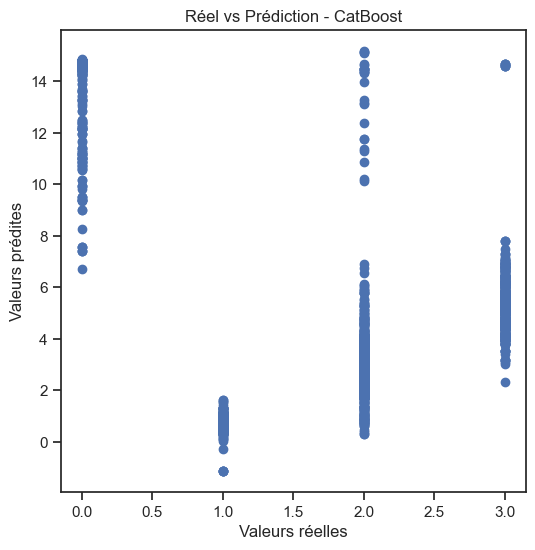

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_cat)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédiction - CatBoost")

plt.show()

Ce graphique compare les valeurs réelles aux valeurs prédites par le modèle.
Plus les points sont proches de la diagonale, plus les prédictions sont précises.

Graphique des Résidus

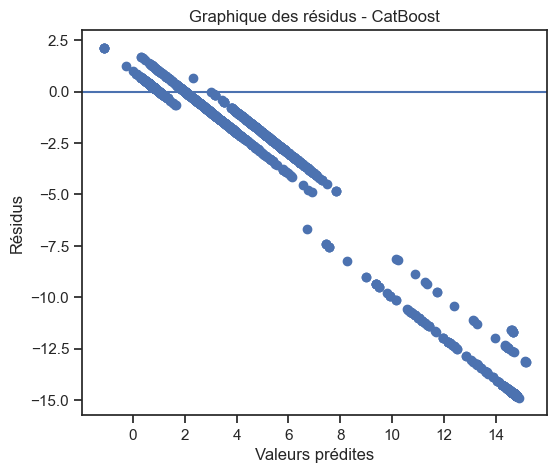

In [ ]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_cat

plt.figure(figsize=(6,5))

plt.scatter( y_pred_cat, residuals)

plt.axhline(y=0)

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")

plt.title("Graphique des résidus - CatBoost")

plt.show()

Le graphique des résidus permet d’analyser les erreurs du modèle.
Une distribution aléatoire autour de zéro indique un bon ajustement du modèle.

Courbe Importance des Variables

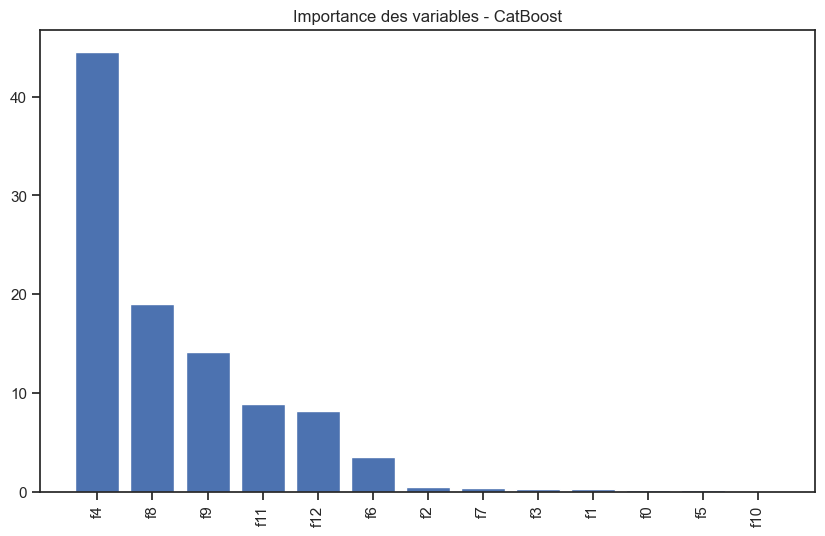

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = cat_model.feature_importances_

feat_importance = pd.DataFrame({
    'Feature': x_train_reg.columns,
    'Importance': importance
})

feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(feat_importance['Feature'], feat_importance['Importance'])

plt.xticks(rotation=90)
plt.title("Importance des variables - CatBoost")

plt.show()

Ce graphique montre les variables les plus influentes dans les prédictions du modèle.

REC Curve

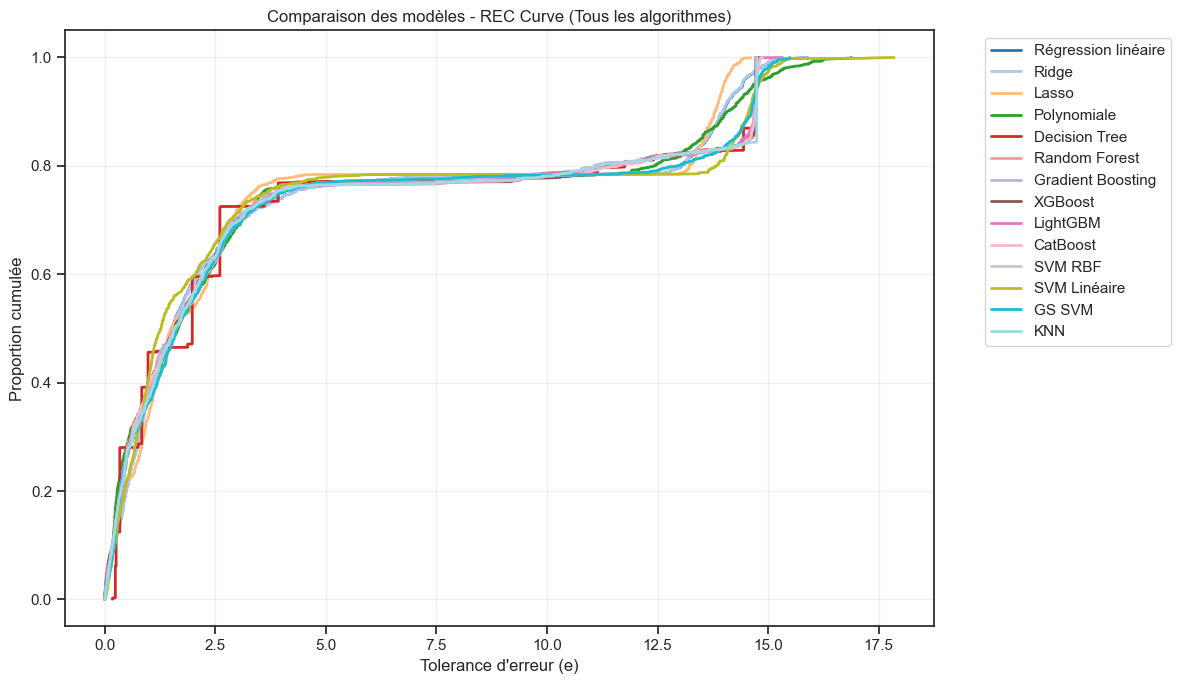

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1) Prédictions des modèles (alignées avec ton tableau)
# =========================================================
models_predictions = {
    "Régression linéaire": y_pred_lr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "Polynomiale": y_pred_poly,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgb,
    "CatBoost": y_pred_cat,
    "SVM RBF": y_pred_rbf,
    "SVM Linéaire": y_pred_linear,
    "GS SVM": y_pred_svm,
    "KNN": y_pred_knn
}

# =========================================================
# 2) Fonction REC Curve
# =========================================================
def rec_curve(y_true, y_pred):
    errors = np.abs(y_true - y_pred)
    sorted_errors = np.sort(errors)
    accuracy = np.arange(1, len(errors) + 1) / len(errors)
    return sorted_errors, accuracy

# =========================================================
# 3) Styles (couleurs automatiques si beaucoup de modèles)
# =========================================================
colors = plt.cm.tab20(np.linspace(0, 1, len(models_predictions)))

# =========================================================
# 4) Plot REC Curve
# =========================================================
plt.figure(figsize=(12, 7))

for i, (name, y_pred) in enumerate(models_predictions.items()):
    thresholds, acc = rec_curve(y_test, y_pred)
    plt.plot(thresholds, acc, label=name, linewidth=2, color=colors[i])

plt.xlabel("Tolerance d'erreur (e)")
plt.ylabel("Proportion cumulée")
plt.title("Comparaison des modèles - REC Curve (Tous les algorithmes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Clustering

# Code complet comme pour cahier des charges

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [ ]:
cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]

df_clean = df[cols].dropna()
X = df_clean.copy()

print("Shape dataset clean :", X.shape)


Shape dataset clean : (9724, 5)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

- ELBOW METHOD

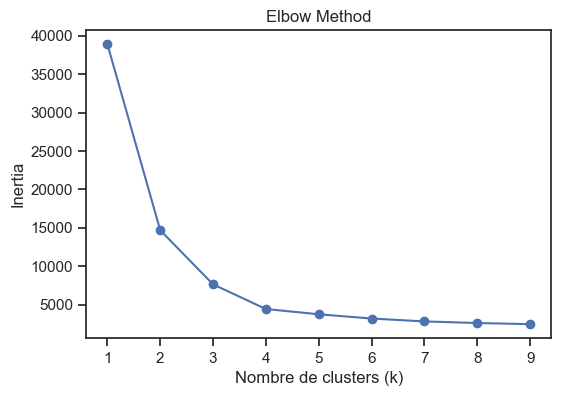

In [ ]:

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
k = 4  

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Ajouter clusters au dataset
df_clustered = df_clean.copy()
df_clustered["Cluster"] = clusters

-. ANALYSE DES CLUSTERS

In [ ]:

cluster_analysis = df_clustered.groupby("Cluster")[cols].mean()
print("\nMoyenne des variables par cluster :")
print(cluster_analysis)



Moyenne des variables par cluster :
              Poids      Volume  Conductivite   Opacite  Rigidite
Cluster                                                          
0        184.054178  355.622787           0.0  0.109028  9.052117
1         27.991640   62.864435           0.0  0.398110  4.044666
2         61.597102  123.434004           0.0  1.026415  8.591934
3         15.053191   33.679128           0.0  1.018170  2.041278


- PCA VISUALISATION

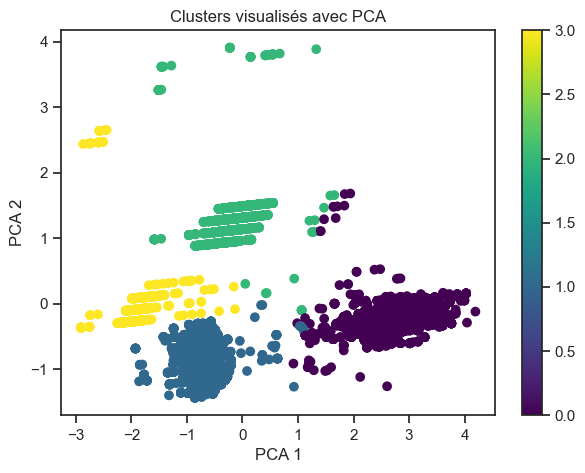

In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Clusters visualisés avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

- SILHOUETTE SCORE et VISUALISATION RELATIONS ENTRE VARIABLES


Silhouette Score : 0.672763213014845


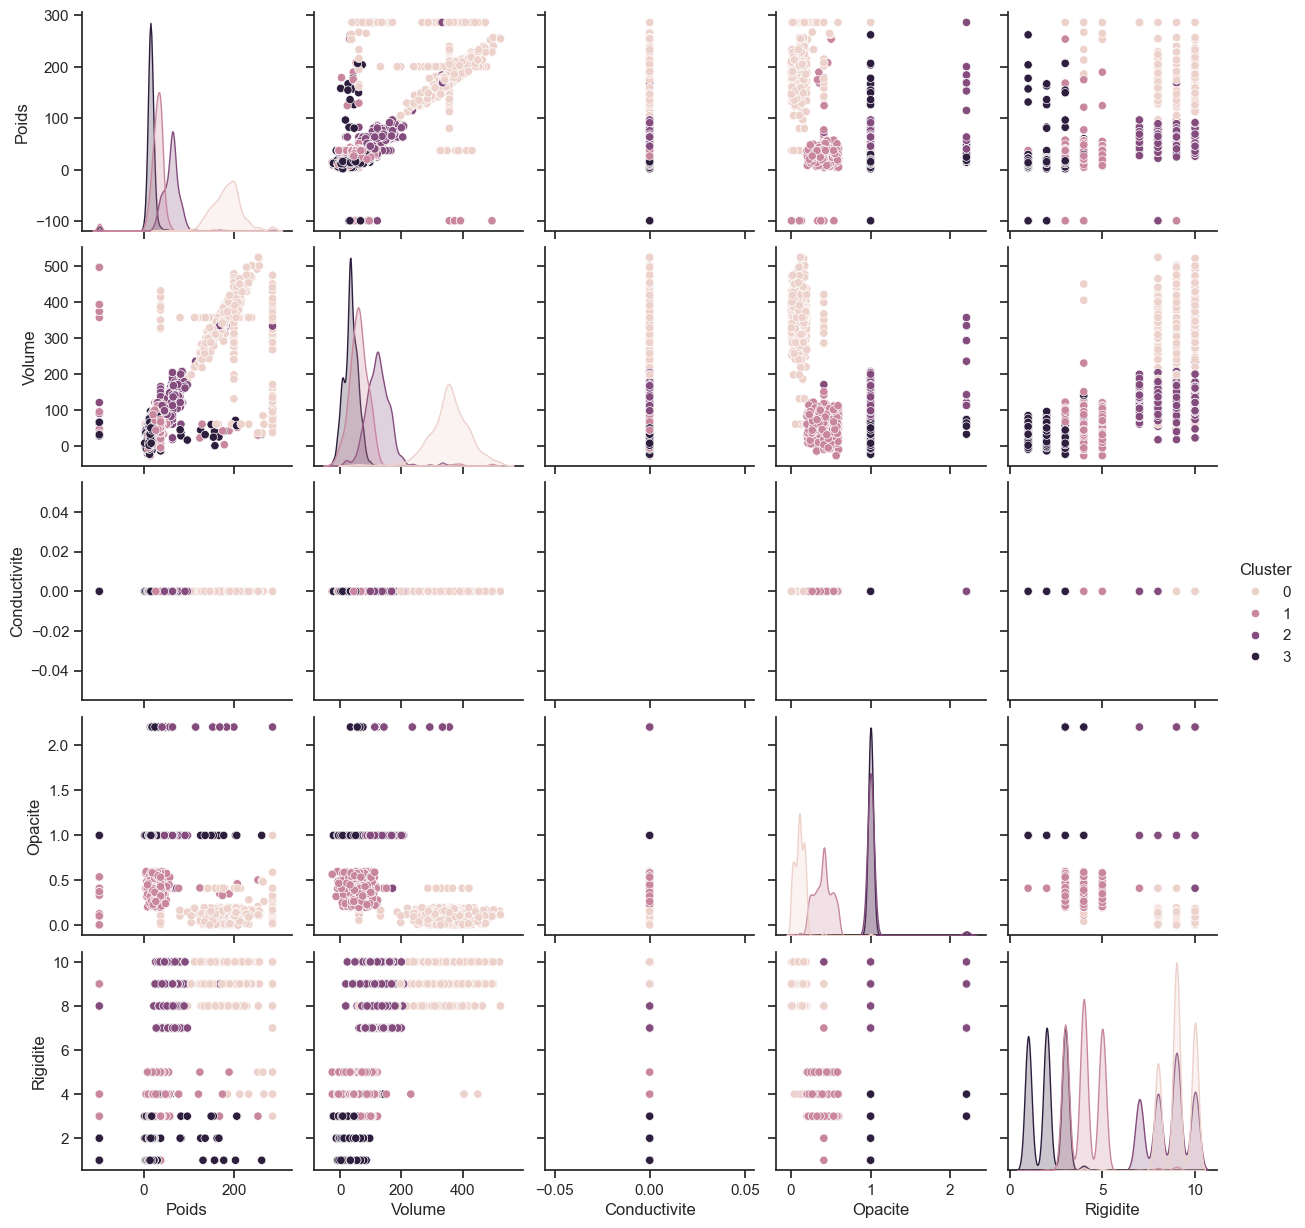

In [ ]:

score = silhouette_score(X_scaled, clusters)
print("\nSilhouette Score :", score)

sns.pairplot(df_clustered, hue="Cluster", vars=cols)
plt.show()


- CROISEMENT AVEC CATEGORIE 

In [ ]:

if "Categorie" in df.columns:
    df_tmp = df.loc[df_clustered.index]
    print(pd.crosstab(df_tmp["Categorie"], df_clustered["Cluster"]))

Cluster       0     1     2     3
Categorie                        
Métal        10     0  2153     0
Papier        0     0     0  2104
Plastique   130  2680   114   149
Verre      2316    29    39     0


Heatmap des moyennes des clusters

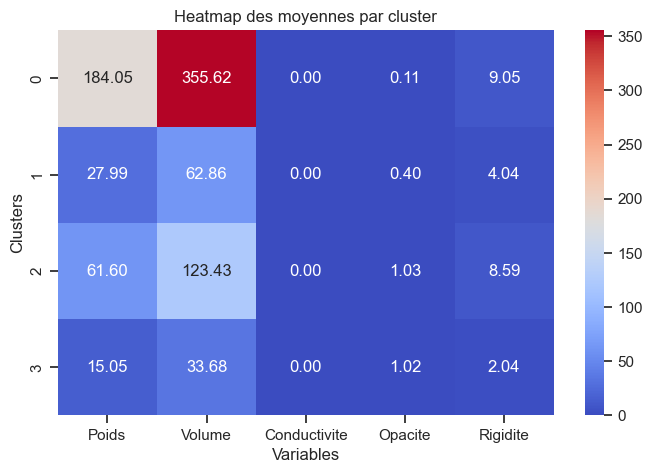

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    cluster_analysis,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Heatmap des moyennes par cluster")
plt.xlabel("Variables")
plt.ylabel("Clusters")

plt.show()

Cette visualisation permet de voir rapidement quelles variables sont fortes ou faibles dans chaque cluster. 

Chaque ligne = un cluster

Chaque colonne = une variable

- Boxplot par cluster

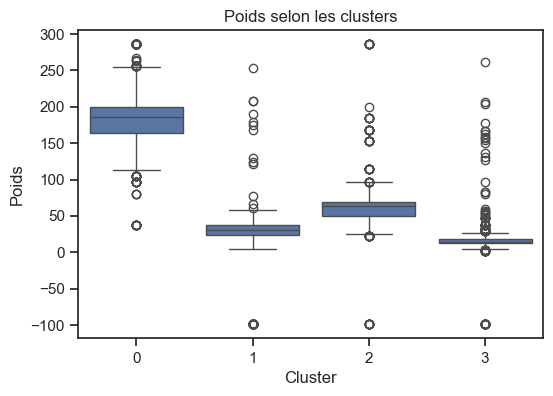

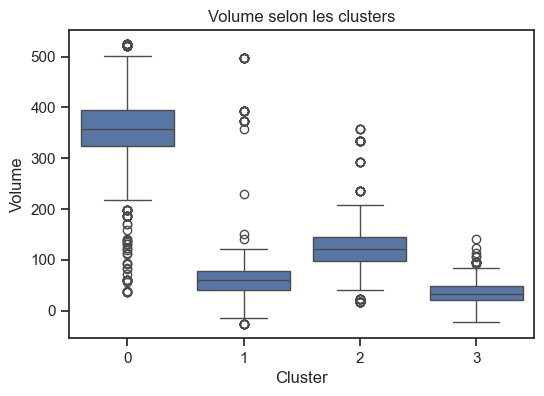

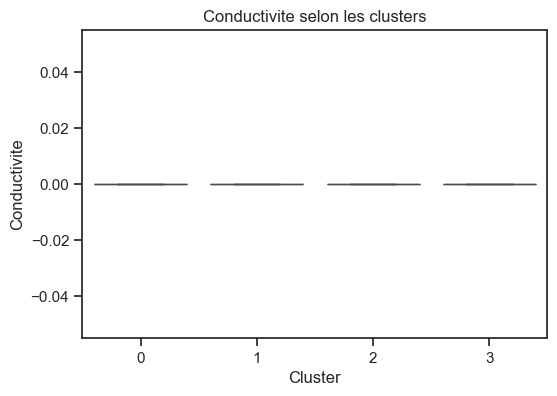

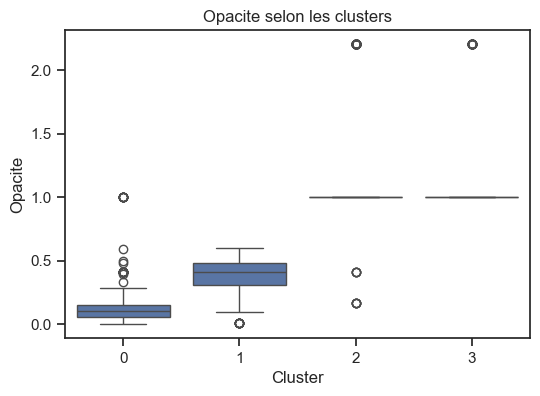

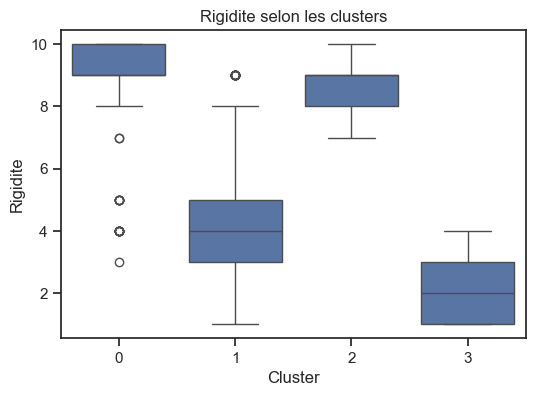

In [ ]:


for col in cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x="Cluster",
        y=col,
        data=df_clustered
    )
    
    plt.title(f"{col} selon les clusters")
    
    plt.show()

Cette visualisation montre la distribution des valeurs dans chaque cluster.
Donc on peut voir :

si un cluster possède des valeurs plus grandes

si les groupes sont bien séparés

si certaines variables discriminent bien les clusters

- Visualisation 3D PCA

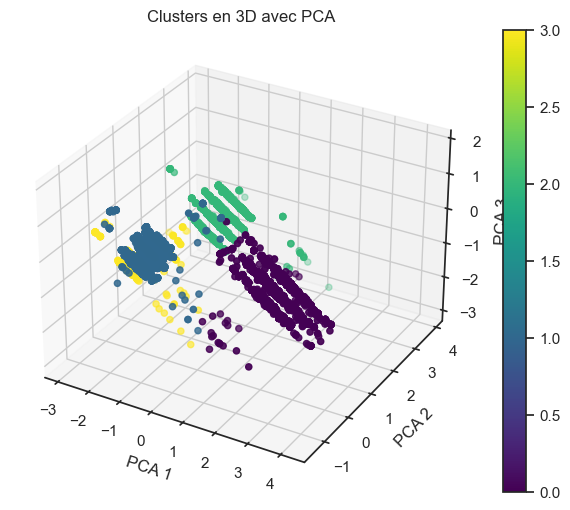

In [ ]:

from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    X_pca_3d[:,2],
    c=clusters,
    cmap='viridis'
)

ax.set_title("Clusters en 3D avec PCA")

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

plt.colorbar(scatter)

plt.show()

===> Les visualisations ont permis d’analyser la séparation des clusters et les caractéristiques dominantes de chaque groupe.
La heatmap facilite la comparaison des moyennes, tandis que les boxplots montrent la distribution et la dispersion des variables dans chaque cluster.

# NLP

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings("ignore")

- Tokenisation + stopwords français + stopwords domaine + stemming

In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer
from nltk.tokenize import word_tokenize

stopwords_fr = set(stopwords.words("french"))

# Stopwords domaine : on supprime les mots spécifiques au projet.
stopwords_domaine = {
    "lot", "dechet", "déchet", "type", "identifie", "identifié",
    "collecte", "collecté", "collectés", "provenance", "site",
    "source", "usine", "centre", "tri", "volume", "poids",
    "prix", "revente", "kg", "litre", "l", "origine",
    "rapport", "materiau", "matériau"
}

stopwords_total = stopwords_fr.union(stopwords_domaine)

stemmer = FrenchStemmer()

def nettoyer_texte(texte):
    texte = str(texte).lower()
    texte = texte.replace("œ", "oe")
    texte = re.sub(r"\d+", " ", texte)
    texte = re.sub(r"[^\w\s]", " ", texte)
    texte = re.sub(r"\s+", " ", texte).strip()
    return texte

def preprocess_nlp(texte):
    texte = nettoyer_texte(texte)

    # Tokenisation : on découpe le texte en mots.
    tokens = word_tokenize(texte, language="french")

    tokens_clean = []
    for mot in tokens:

        # Stopwords français + domaine : on supprime les mots inutiles.
        if mot not in stopwords_total and len(mot) > 2:

            # Stemming : on réduit le mot à sa racine.
            mot_stem = stemmer.stem(mot)

            tokens_clean.append(mot_stem)

    return " ".join(tokens_clean)

df["texte_clean"] = df["Rapport_Collecte"].apply(preprocess_nlp)

df[["Rapport_Collecte", "texte_clean", "Categorie"]].head()

- SÉPARATION TRAIN / TEST

In [ ]:

from sklearn.model_selection import train_test_split

X = df["texte_clean"]
y = df["Categorie"]

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", x_train.shape)
print("Test  :", x_test.shape)
print(y_train.value_counts())

Train : (7779,)
Test  : (1945,)
Categorie
Plastique    2458
Verre        1907
Métal        1731
Papier       1683
Name: count, dtype: int64


- FONCTION D'ÉVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

resultats = []

def evaluer_modele(nom_vectorisation, nom_modele, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    resultats.append({
        "Vectorisation": nom_vectorisation,
        "Modèle": nom_modele,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

    print("="*70)
    print(f"{nom_vectorisation} + {nom_modele}")
    print("="*70)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred))
    print("\nMatrice de confusion:\n")
    print(confusion_matrix(y_test, y_pred))

-  BAG OF WORDS

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

bow_vectorizer = CountVectorizer()

X_train_bow = bow_vectorizer.fit_transform(x_train)
X_test_bow = bow_vectorizer.transform(x_test)

modeles_classiques = {
    "Naive Bayes Multinomial": MultinomialNB(),
    "Régression Logistique": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "LinearSVC": LinearSVC(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}

for nom, modele in modeles_classiques.items():
    modele.fit(X_train_bow, y_train)
    y_pred = modele.predict(X_test_bow)
    evaluer_modele("Bag of Words", nom, y_test, y_pred)

Bag of Words + Naive Bayes Multinomial
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945


Matrice de confusion:

[[432   0   0   0]
 [  0 421   0   0]
 [  0   0 615   0]
 [  0   0   0 477]]
Bag of Words + Régression Logistique
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
 

- TF-IDF uni + bigrammes

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
X_test_tfidf = tfidf_vectorizer.transform(x_test)

for nom, modele in modeles_classiques.items():
    modele.fit(X_train_tfidf, y_train)
    y_pred = modele.predict(X_test_tfidf)
    evaluer_modele("TF-IDF uni+bigrammes", nom, y_test, y_pred)

TF-IDF uni+bigrammes + Naive Bayes Multinomial
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945


Matrice de confusion:

[[432   0   0   0]
 [  0 421   0   0]
 [  0   0 615   0]
 [  0   0   0 477]]
TF-IDF uni+bigrammes + Régression Logistique
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      

- WORD2VEC

In [ ]:
from gensim.models import Word2Vec

phrases_train = [texte.split() for texte in x_train]
phrases_test = [texte.split() for texte in x_test]

word2vec_model = Word2Vec(
    sentences=phrases_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    seed=42
)

def vectoriser_moyenne(tokens, modele, taille=100):
    vecteurs = []
    for mot in tokens:
        if mot in modele.wv:
            vecteurs.append(modele.wv[mot])

    if len(vecteurs) == 0:
        return np.zeros(taille)

    return np.mean(vecteurs, axis=0)

X_train_w2v = np.array([
    vectoriser_moyenne(tokens, word2vec_model, 100)
    for tokens in phrases_train
])

X_test_w2v = np.array([
    vectoriser_moyenne(tokens, word2vec_model, 100)
    for tokens in phrases_test
])

modeles_embeddings = {
    "Régression Logistique": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "LinearSVC": LinearSVC(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}

for nom, modele in modeles_embeddings.items():
    modele.fit(X_train_w2v, y_train)
    y_pred = modele.predict(X_test_w2v)
    evaluer_modele("Word2Vec", nom, y_test, y_pred)

Word2Vec + Régression Logistique
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945


Matrice de confusion:

[[432   0   0   0]
 [  0 421   0   0]
 [  0   0 615   0]
 [  0   0   0 477]]
Word2Vec + LinearSVC
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00

- FASTTEXT

In [ ]:
from gensim.models import FastText

fasttext_model = FastText(
    sentences=phrases_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    seed=42
)

X_train_fasttext = np.array([
    vectoriser_moyenne(tokens, fasttext_model, 100)
    for tokens in phrases_train
])

X_test_fasttext = np.array([
    vectoriser_moyenne(tokens, fasttext_model, 100)
    for tokens in phrases_test
])

for nom, modele in modeles_embeddings.items():
    modele.fit(X_train_fasttext, y_train)
    y_pred = modele.predict(X_test_fasttext)
    evaluer_modele("FastText", nom, y_test, y_pred)

FastText + Régression Logistique
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945


Matrice de confusion:

[[432   0   0   0]
 [  0 421   0   0]
 [  0   0 615   0]
 [  0   0   0 477]]
FastText + LinearSVC
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00

- TF-IDF + LinearSVC

In [ ]:
from sklearn.pipeline import Pipeline

pipeline_nlp = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1,   
        max_df=0.9,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

pipeline_nlp.fit(x_train, y_train)

y_pred_final = pipeline_nlp.predict(x_test)

evaluer_modele("Pipeline TF-IDF", "LinearSVC final", y_test, y_pred_final)

Pipeline TF-IDF + LinearSVC final
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945


Matrice de confusion:

[[432   0   0   0]
 [  0 421   0   0]
 [  0   0 615   0]
 [  0   0   0 477]]


- SAUVEGARDER LE MODÈLE

In [ ]:
import joblib

joblib.dump(pipeline_nlp, "modele_nlp_tfidf_linearsvc.pkl")
joblib.dump(preprocess_nlp, "fonction_preprocess_nlp.pkl")

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


- CHARGER LE MODÈLE ET PRÉDIRE

In [ ]:
modele_charge = joblib.load("modele_nlp_tfidf_linearsvc.pkl")

def predire_categorie_nlp(texte):
    texte_clean = preprocess_nlp(texte)
    pred = modele_charge.predict([texte_clean])[0]

    texte_lower = texte.lower()

    if "aluminium" in texte_lower or "métal" in texte_lower:
        return "Métal"
    if "carton" in texte_lower or "papier" in texte_lower:
        return "Papier"
    if "plastique" in texte_lower:
        return "Plastique"
    if "verre" in texte_lower:
        return "Verre"

    return pred

print("canette métallique conductrice =>", predire_categorie_nlp("canette métallique conductrice"))
print("bouteille transparente cassante =>", predire_categorie_nlp("bouteille transparente cassante"))
print("carton journal feuille =>", predire_categorie_nlp("carton journal feuille"))
print("sachet plastique souple =>", predire_categorie_nlp("sachet plastique souple"))
print("bouteille transparente recyclée en verre =>", predire_categorie_nlp("bouteille transparente recyclée en verre"))
print("sac plastique souple utilisé pour emballage alimentaire =>", predire_categorie_nlp("sac plastique souple utilisé pour emballage alimentaire"))
print("boite en aluminium conductrice et rigide =>", predire_categorie_nlp("boite en aluminium conductrice et rigide"))
print("journal ancien en papier recyclé =>", predire_categorie_nlp("journal ancien en papier recyclé"))
print("film plastique léger et flexible =>", predire_categorie_nlp("film plastique léger et flexible"))
print("canette de soda en métal recyclable =>", predire_categorie_nlp("canette de soda en métal recyclable"))
print("bocal en verre cassable et transparent =>", predire_categorie_nlp("bocal en verre cassable et transparent"))
print("carton d’emballage épais et recyclable =>", predire_categorie_nlp("carton d’emballage épais et recyclable"))
print("feuille papier imprimée utilisée au bureau =>", predire_categorie_nlp("feuille papier imprimée utilisée au bureau"))
print("barquette plastique utilisée pour nourriture =>", predire_categorie_nlp("barquette plastique utilisée pour nourriture"))
print("pièce métallique conductrice lourde =>", predire_categorie_nlp("pièce métallique conductrice lourde"))
print("verre fragile utilisé pour les fenêtres =>", predire_categorie_nlp("verre fragile utilisé pour les fenêtres"))

canette métallique conductrice => Métal
bouteille transparente cassante => Verre
carton journal feuille => Papier
sachet plastique souple => Plastique
bouteille transparente recyclée en verre => Verre
sac plastique souple utilisé pour emballage alimentaire => Plastique
boite en aluminium conductrice et rigide => Métal
journal ancien en papier recyclé => Papier
film plastique léger et flexible => Plastique
canette de soda en métal recyclable => Métal
bocal en verre cassable et transparent => Verre
carton d’emballage épais et recyclable => Papier
feuille papier imprimée utilisée au bureau => Papier
barquette plastique utilisée pour nourriture => Plastique
pièce métallique conductrice lourde => Métal
verre fragile utilisé pour les fenêtres => Verre
